In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og
import src.colabfold.colabfold as cf
import src.unitprot as up 
import src.analysis.attributions as ab
import src.analysis.matrices as mc

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import numpy as np  
import glob

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 859637 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [6]:
# refseq_ids = ['NP_009225.1'] # BRCA1
refseq_ids = ['NP_000101.2'] # DYPD 

vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']=="esm1_t34_670M_UR50D") & 
                            (vep_files['protein'].isin(refseq_ids))]
    )
print("n_haplotypes: ", vep_df["haplotype"].nunique())
vep_df["HGNC"] = vep_df["GENEINFO"].str.split(":").str[0] 
vep_df['site'] = vep_df['protein'] + ":" + vep_df['mutant'] 
vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 160 masked-marginals parquet files


Reading files:   0%|          | 0/160 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 5.46GB/s]


VEP dataframe shape: (800, 72)
n_haplotypes:  160


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC,site
0,ENSP00000359211:1023P>S,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Q972R,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,-2.076286,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97079139,715550,T,C,.,PASS,715550,1:97079139,C,1806,NM_000110.4,Transcript,missense_variant,3027,2915,972,Q/R,cAg/cGg,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000110.4:c.2915A>G,NP_000101.2:p.Gln972Arg,-,0.00108,0.00024,719145,MedGen:CN517202,not_provided,NC_000001.11:g.97079139T>C,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,145529148,0.0006,NaN,NaN,NaN,NaN,NaN,NaN,-0.591501,0.000351,6,likely_benign,DPYD,NP_000101.2:Q972R
1,ENSP00000359211:1023P>S,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V902A,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,0.656864,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97098550,2236534,A,G,.,PASS,2236534,1:97098550,G,1806,NM_000110.4,Transcript,missense_variant,2817,2705,902,V/A,gTa/gCa,-,MODERATE,-,-1,-,-,-,A,A,-,NM_000110.4:c.2705T>C,NP_000101.2:p.Val902Ala,-,NaN,NaN,2228561,"MeSH:D030342,MedGen:C0950123",Inborn_genetic_diseases,NC_000001.11:g.97098550A>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806|DPYD-AS1:100873932,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525650,0.002001,6,likely_benign,DPYD,NP_000101.2:V902A
2,ENSP00000359211:1023P>S,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V482I,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,0.180161,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97549640,2235853,C,T,.,PASS,2235853,1:97549640,T,1806,NM_000110.4,Transcript,missense_variant,1556,1444,482,V/I,Gtc/Atc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000110.4:c.1444G>A,NP_000101.2:p.Val482Ile,-,NaN,NaN,2231338,"MeSH:D030342,MedGen:C0950123",Inborn_genetic_diseases,NC_000001.11:g.97549640C>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.506614,0.001856,6,likely_benign,DPYD,NP_000101.2:V482I
3,ENSP00000359211:1023P>S,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V427A,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,-9.896472,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97573819,1677165,A,G,.,PASS,1677165,1:97573819,G,1806,NM_000110.4,Transcript,missense_variant,1392,1280,427,V/A,gTc/gCc,-,MODERATE,-,-1,-,-,-,A,A,-,NM_000110.4:c.1280T>C,NP_000101.2:p.Val427Ala,-,NaN,NaN,1668797,MedGen:CN169374,not_specified,NC_000001.11:g.97573819A>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.254382,-0.010700,6,likely_benign,DPYD,NP_000101.2:V427A
4,ENSP00000359211:1023P>S,NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,P86L,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKH

### Merge haplotypes

In [7]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


Merging haplotype datasets: 0it [00:00, ?it/s]

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 162 haplotypes across 1 tx_ids.


In [8]:
haps_df= hs.get_haplotype_names(haplotypes=haplotypes, 
                                as_df=True, 
                                split_variants=True) 

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True, 
                                           verbose=True)
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Adding REF haplotypes to the DataFrame
Samples after adding REF haplotypes: 3827
Final shape: (7665, 16)
>> haplotype(s): 162
>> cohort(s): 3
>> cohort_sample(s): 3832
>> sample(s): 3827
>> population(s): 159
>> superpopulation(s): 9
>> sex(s): 2


,ENST_haplosaurus,cohort_sample,haplotype,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections,population_code
0,ENST00000370192,GGVP:HG02613,ENSP00000359211:REF,GGVP,REF,2,0,<NA>,SAME1840390,GWD,REF,REF,REF,REF,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
0,ENST00000370192,GGVP:HG02613,ENSP00000359211:REF,GGVP,HG02613,2,0,male,SAME1840390,GWD,Gambian Mandinka,AFR,African Ancestry,GWD,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
1,ENST00000370192,GGVP:HG02613,"ENSP00000359211:29C>R,543I>V",GGVP,HG02613,2,1,male,SAME1840390,GWD,Gambian Mandinka,AFR,African Ancestry,GWD,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
2,ENST00000370192,1000GENOMES:phase_3:HG00867,ENSP00000359211:REF,1000GENOMES,HG00867,2,0,female,SAME123550,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
3,ENST00000370192,1000GENOMES:phase_3:HG00867,"ENSP00000359211:74R>*,75del{952}",1000GENOMES,HG00867,2,1,female,SAME123550,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN


## WT variant attribution analysis

Identify the WT variants (observed naturally occurring  in the  biobank cohort). 
Then find how frequency those variants are (inferred by extracting them from the haplotype names after expanding the data from the unique haplotype --> individual level).

Using side-by-side heatmaps we can find superpopulation x WT variant clusters that are frequent in a given superpopulation and/or high mean VEP (across all injected variants). 

In this way, we can identify (superpopulation-specific) WT variants that confer sensitivity to ClinVar variants in general.  

We could also recompute this plot to show only average VEP for a specific ClinVar variant of interest to see which WT variants confer sensitivity to it.

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using all 3 cohorts.
Using 38 populations
Adding haplotype frequencies per population
Adding top superpopulation
0 samples are missing superpopulation metadata
0 samples are missing superpopulation metadata

Number of variants specific to each population:
specific_population
GGVP:GWD                   6
1000GENOMES:phase_3:YRI    6
1000GENOMES:phase_3:MXL    5
1000GENOMES:phase_3:BEB    5
1000GENOMES:phase_3:TSI    5
1000GENOMES:phase_3:PJL    5
GGVP:GWJ                   4
1000GENOMES:phase_3:STU    3
1000GENOMES:phase_3:CLM    3
GGVP:GWW                   3
1000GENOMES:phase_3:ACB    3
1000GENOMES:phase_3:ASW    3
1000GENOMES:phase_3:JPT    3
1000GENOMES:phase_3:CDX    3
1000GENOMES:phase_3:IBS    3
1000GENOMES:phase_3:CHS    3
1000GENOMES:phase_3:FIN    3
1000GENOMES:phase_3:KHV    2
1000GENOMES:phase_3:ESN    2
1000GENOMES:phase_3:GBR    2
1000GENOMES:phase_3:CEU    2
1000GENOMES:phase_3:LWK    1
1000GENOMES:phase_3:GIH    1
1000GENOMES:phase_3:ITU    1
1000GENOMES:phase_3:PEL    1

/home/schilder/projects/VEP_protein/src/vep_analysis.py:2781: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  var_freqs_agg = var_freqs_agg.fillna(fillna)


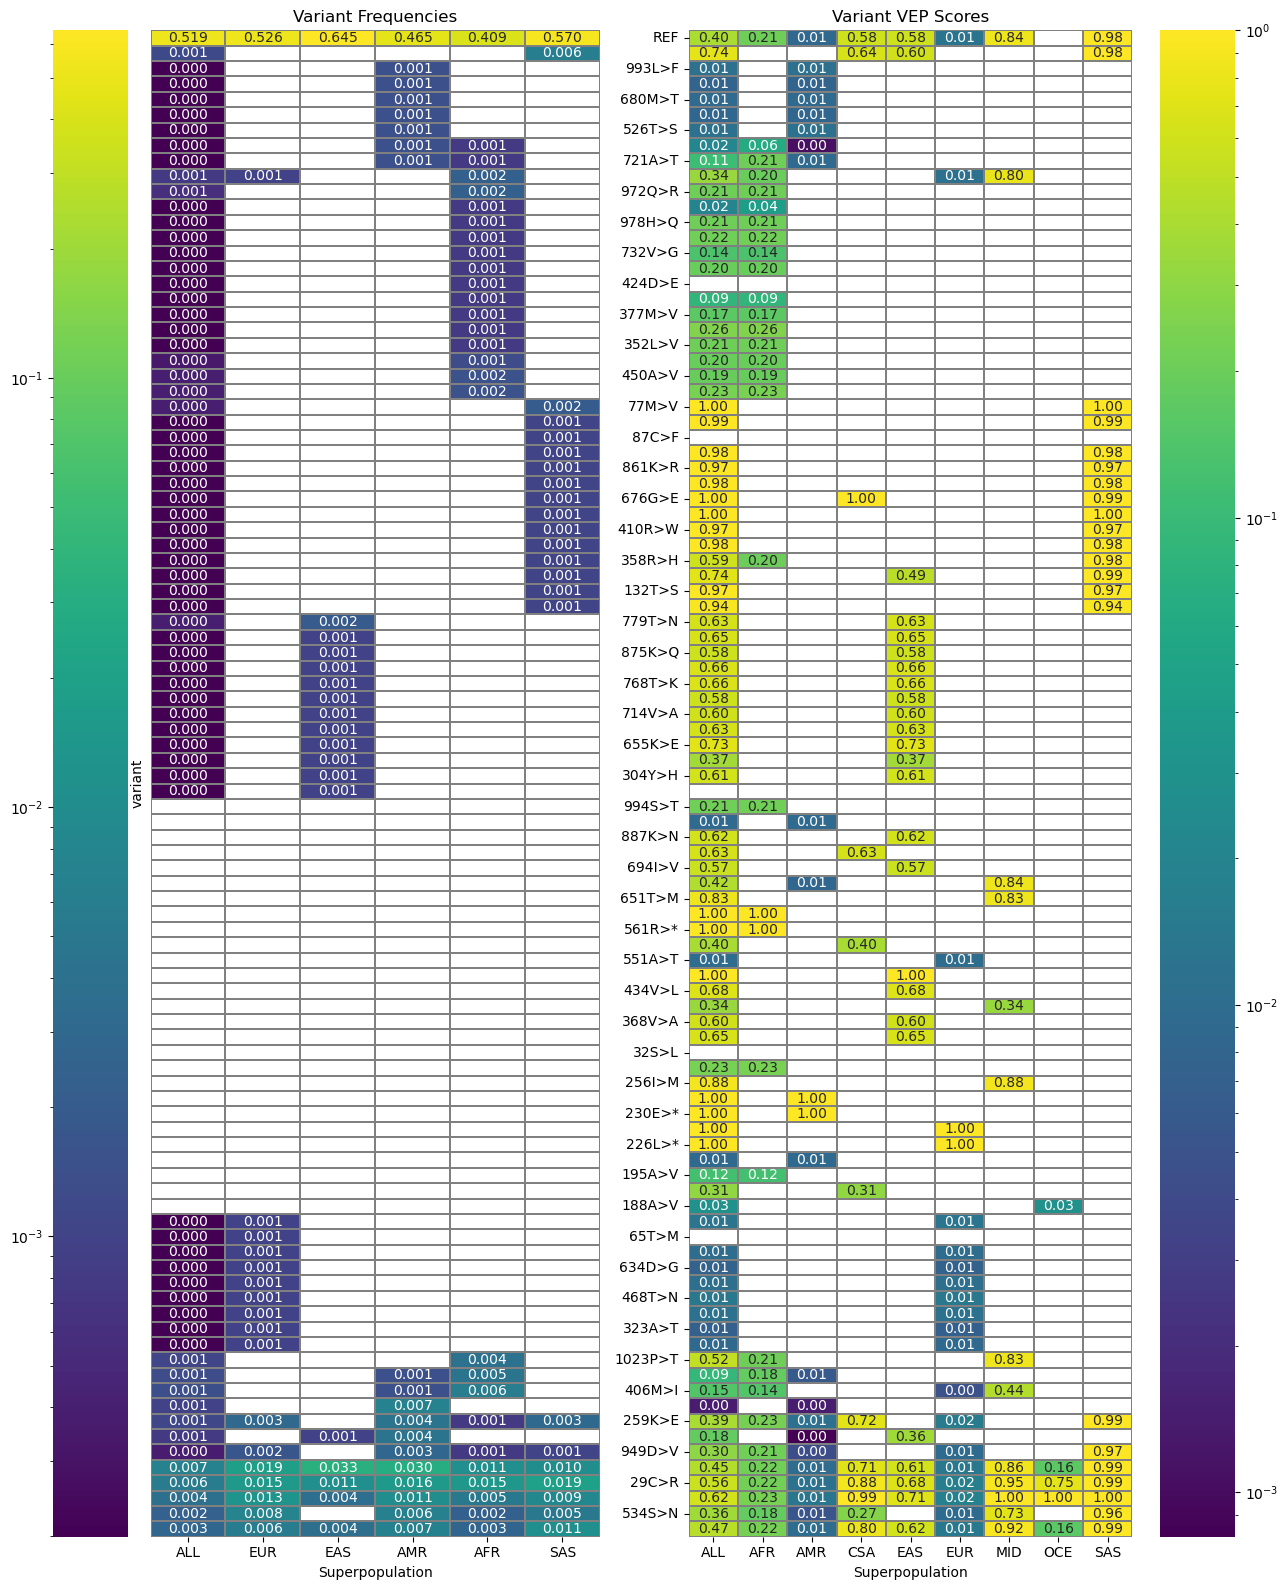

In [ ]:
vep_prot, var_vep_agg, var_freqs_agg, fig = ab.get_wt_variant_vep_scores(vep_df=vep_df, 
                                                                        haps_df=haps_df,
                                                                        haplotypes=haplotypes, 
                                                                        haps_to_samples=haps_to_samples
                                                                        )

### Dotplot

Same information as the dual heatmaps above, but condense into a single dotplot where the size is the variant frequency and the color is the mean VEP score.

In [187]:
# va.plot_wt_variant_vep_scores_dotplot(var_vep_agg, var_freqs_agg)

## Clinical variant x Individual heatmap

(38305, 89)


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Number of col clusters: 2


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


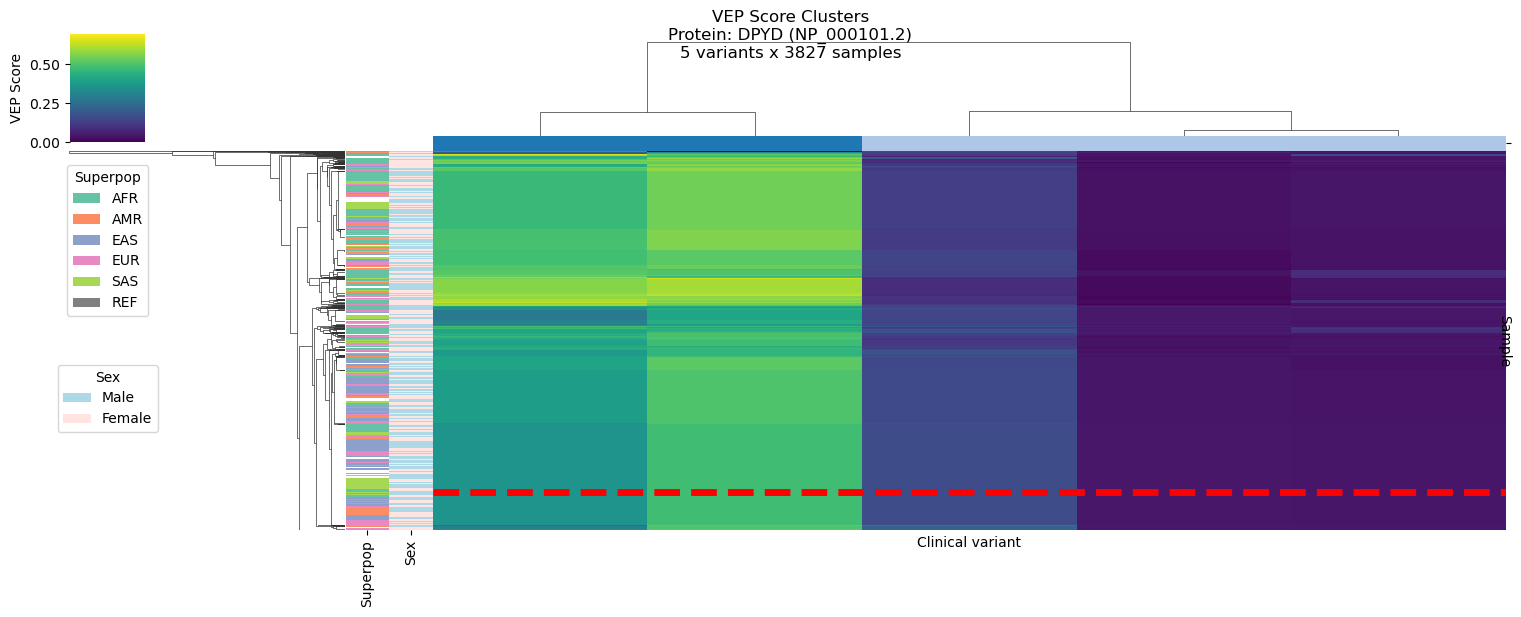

In [ ]:
g1, variant_to_cluster = ab.sample_by_mutant_clustermap(vep_df, 
                                                        haps_to_samples, 
                                                        figsize=(15,6),
                                                        t=1.15)

## Clinical variant x WT variant sensitization heatmap

Compare mean VEP across WT variants for each injected ClinVar variant.

Adding positions to WT variants
Adding positions to clinical variants
Sorting clinical variants by WT variant positions
Creating color palettes
Inverting scale
Normalizing columns
Creating column colors
Reindexing column colors
Creating row colors
Reindexing row colors
Dropping position column from column colors
Dropping position column from row colors
Creating mask
Creating clustermap


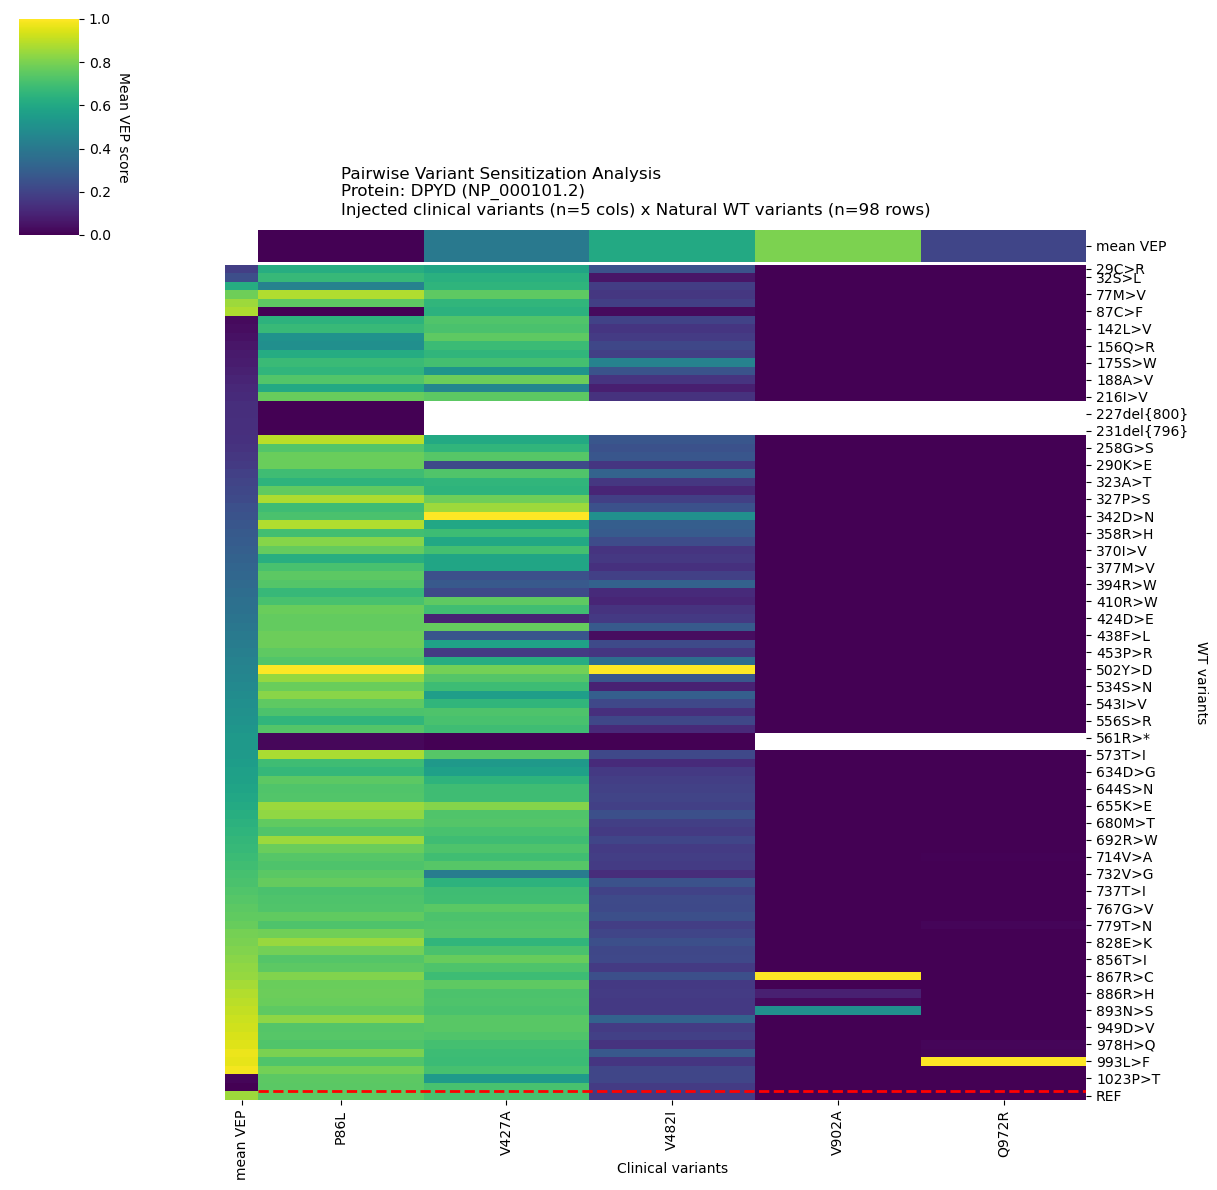

In [ ]:
g0, clinical_vs_wt, row_colors, col_colors = ab.pairwise_variant_sensitization_clustermap(
                                          vep_prot=vep_prot, 
                                            figsize=(12,12),
                                            row_cluster=False,
                                            col_cluster=False,
                                              normalize_procedure=["cols"],
                                             title_y=1.05,
                                        #    show_position_per_col=True ,
                                        #     show_position_per_row=True,
                                             pow=10,
                                             ) 

## 2D protein structure

### Import from PDB

The Protein Data Bank (PDB) utilizes two primary file formats for storing and exchanging protein structure information: the legacy PDB format and the more modern CIF (Crystallographic Information Framework) format, also known as PDBx/mmCIF. The CIF format is derived from the STAR format and has been adopted as the standard for deposition since 2014 due to limitations in the original PDB format. 

Here's a comparison of the key features of each format:
1. PDB Format:
Fixed-width format: Data fields are allocated a predetermined number of characters, which can be limiting for large protein complexes exceeding the assigned space.
Legacy format: While widely used due to its long history, the fixed-width format poses limitations, especially with larger protein complexes, and is being phased out.
Structure: Each line, or record, begins with a record name (e.g., "ATOM," "HETATM"), followed by data fields arranged in specific columns. 

2. CIF (PDBx/mmCIF) Format:
Expandable format: The CIF format uses a label-value structure, where data is explicitly named and separated by spaces, allowing for unlimited data content without encountering size restrictions.
Data blocks: CIF files are constructed by concatenating data blocks, each containing label and data columns.
PDB Standard: The CIF format has been the standard for PDB deposition since 2014.
Improved data representation: mmCIF enhances the representation of additional information alongside the atomic coordinates, unlike the limited support in the legacy PDB format. 

In summary: 

- PDB files: Older, fixed-width format, useful for smaller protein structures, but less flexible for large complexes. Still widely used for compatibility with older software.
- CIF files (PDBx/mmCIF): Newer, expandable format with no size restrictions, better suited for large macromolecular structures. The standard for new PDB depositions. 
It's important to note that while the CIF format is the preferred standard, many bioinformatics tools and programs continue to support the legacy PDB format. Conversion tools are available to facilitate the transition between formats. 

In [13]:
# structure = cf.import_pdb("https://alphafold.ebi.ac.uk/files/AF-Q8CGX5-F1-model_v4.pdb") 

# # Calculate the contact map
# contact_map = cf.get_contact_map(structure)

# # Plot the contact map
# plt.matshow(contact_map, cmap='binary')
# plt.title("Protein Contact Map")
# plt.xlabel("Residue Index")
# plt.ylabel("Residue Index")
# plt.show() 

### Import from mmCIF

In [ ]:
uniprot_gene = "BRCA1" # DYPD
uniprot_ids = {"BRCA1":"P38398", "DYPD":"Q12882"}
uniprot_id = uniprot_ids[uniprot_gene]

File /home/schilder/.cache/alphafold_db/cif/AF-Q12882-F1-model_v4.cif already exists, skipping download.


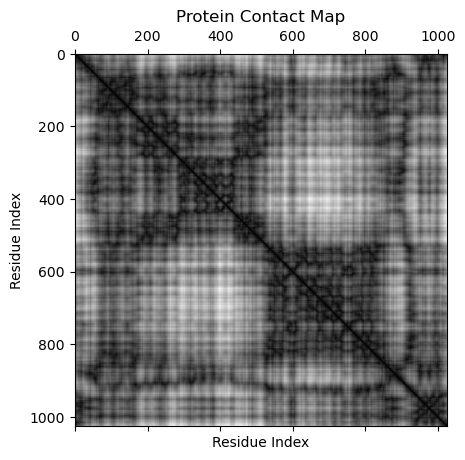

In [ ]:
structure = cf.import_mmcif(protein_id = uniprot_id)[0]

contact_map = cf.get_contact_map(structure, 
                                 max_distance=8.0, 
                                 continuous=True, 
                                 return_distance_map=True )

plt.matshow(contact_map, cmap='binary')
plt.title("Protein Contact Map")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()

In [16]:
plddt_df = cf.get_plddt(structure)

print(plddt_df["pLDDT"].describe())
print(plddt_df["confidence_category"].value_counts())
plddt_df.head()

count    1025.000000
mean       96.255395
std         6.324608
min        37.030000
25%        96.550000
50%        98.130000
75%        98.670000
max        98.960000
Name: pLDDT, dtype: float64
confidence_category
very_high    969
high          36
low           16
very_low       4
Name: count, dtype: int64


,residue,pLDDT,confidence_category,confidence_label,confidence_color
0,1,67.39,low,Low (70 > pLDDT > 50),#FFDB13
1,2,81.35,high,High (90 > pLDDT > 70),#65CBF3
2,3,88.72,high,High (90 > pLDDT > 70),#65CBF3
3,4,93.44,very_high,Very high (pLDDT > 90),#0053D6
4,5,93.92,very_high,Very high (pLDDT > 90),#0053D6


<Figure size 1000x1000 with 0 Axes>

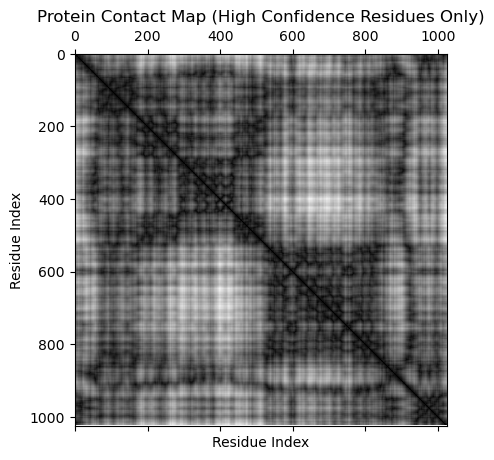

In [17]:
# contact_map
plddt_high = plddt_df.loc[plddt_df["pLDDT"] > 50]
# Filter contact map to only include high confidence residues
contact_map_high_conf = contact_map.copy()
contact_map_high_conf[~plddt_df["residue"].isin(plddt_high["residue"])] = np.nan

# Plot filtered contact map
plt.figure(figsize=(10,10))
plt.matshow(contact_map_high_conf, cmap='binary')
plt.title("Protein Contact Map (High Confidence Residues Only)")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()


In [18]:
vep_prot = utils.variants_to_positions(vep_prot)
vep_prot.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC,site,variant,variant_VEP_mean,variant_VEP_std,variant_position
1379,"ENSP00000359211:29C>R,166M>V,226L>*,227del{800}",NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,P86L,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Pathogenic,-9.824974,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97740456,1028072,None,None,.,PASS,1028072,1:97740456,A,1806,NM_000110.4,Transcript,missense_variant,369,257,86,P/L,cCg/cTg,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000110.4:c.257C>T,NP_000101.2:p.Pro86Leu,-,NaN,0.00007,1015813,"MedGen:CN517202|MONDO:MONDO:0010130,MedGen:C19...",not_provided|Dihydropyrimidine_dehydrogenase_d...,NC_000001.11:g.97740456G>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,568132506,0.0002,NaN,NaN,NaN,NaN,NaN,NaN,-10.272109,-0.017623,6,likely_path,DPYD,NP_000101.2:P86L,227del{800},-9.824974,NaN,227
1362,"ENSP00000359211:29C>R,166M>V,226L>*,227del{800}",NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Q972R,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,NaN,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97079139,715550,L,*,.,PASS,715550,1:97079139,C,1806,NM_000110.4,Transcript,missense_variant,3027,2915,972,Q/R,cAg/cGg,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000110.4:c.2915A>G,NP_000101.2:p.Gln972Arg,-,0.00108,0.00024,719145,MedGen:CN517202,not_provided,NC_000001.11:g.97079139T>C,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806,SO:0001583|missense_variant,1,145529148,0.0006,NaN,NaN,NaN,NaN,NaN,NaN,-0.591501,0.000351,6,likely_benign,DPYD,NP_000101.2:Q972R,226L>*,-9.824974,NaN,226
1366,"ENSP00000359211:29C>R,166M>V,226L>*,227del{800}",NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,V902A,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Benign,NaN,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97098550,2236534,L,*,.,PASS,2236534,1:97098550,G,1806,NM_000110.4,Transcript,missense_variant,2817,2705,902,V/A,gTa/gCa,-,MODERATE,-,-1,-,-,-,A,A,-,NM_000110.4:c.2705T>C,NP_000101.2:p.Val902Ala,-,NaN,NaN,2228561,"MeSH:D030342,MedGen:C0950123",Inborn_genetic_diseases,NC_000001.11:g.97098550A>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,DPYD:1806|DPYD-AS1:100873932,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525650,0.002001,6,likely_benign,DPYD,NP_000101.2:V902A,226L>*,-9.824974,NaN,226
1378,"ENSP00000359211:29C>R,166M>V,226L>*,227del{800}",NP_000101.2,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,P86L,MAPVLSKDSADIESILALNPRTQTHATLCSTSAKKLDKKHWKRNPD...,Pathogenic,-9.824974,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000359211,ENST00000370192,False,1,97740456,1028072,L,*,.,PASS,1028072,1:97740456,A,1806,NM_000110.4,Transcript,missense_variant,369,257,86,P/L,cCg/cTg,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000110.4:c.257C>T,NP_000101.2:p.Pro86Leu,-,NaN,0.00007,1015813,"MedGen:CN517202|MONDO:MONDO:0010130,MedGen:C19...",not_provided|Dihydropyr

### Plot sensitization map

97
(5, 16)
Adding rectangles
97


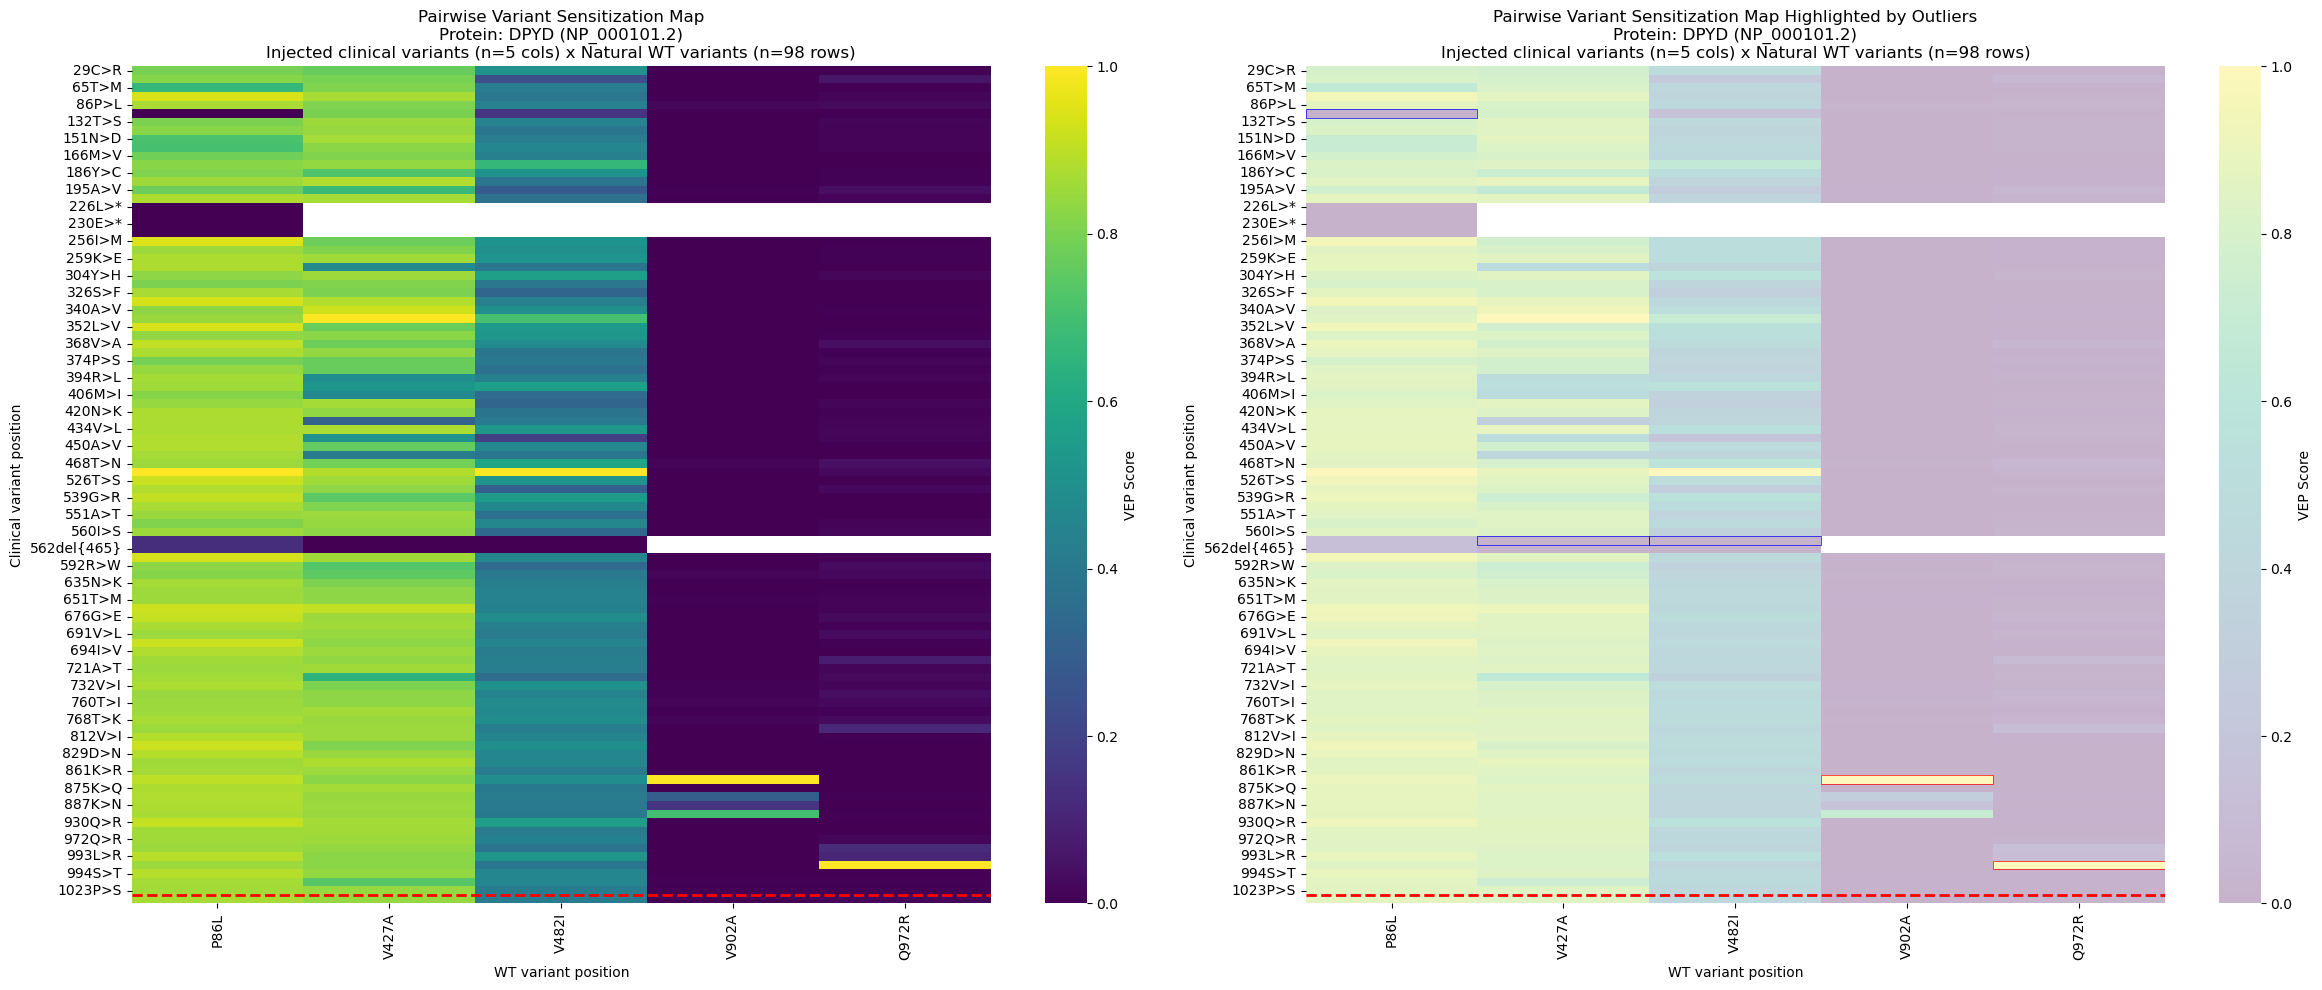

In [ ]:
plot_sensitization_maps_out = ab.plot_sensitization_maps(clinical_vs_wt, vep_prot)

outlier_df = plot_sensitization_maps_out['data']['outlier_df']
outlier_sig = plot_sensitization_maps_out['data']['outlier_sig']

outlier_sig.head()

### Plot sensitization map: expanded matrix

Normalizing columns
Expanding x-axis by 3
Expanding y-axis by 3


/home/schilder/projects/VEP_protein/src/colabfold.py:408: RuntimeWarning: All-NaN slice encountered
  return agg_func(


Adding rectangles


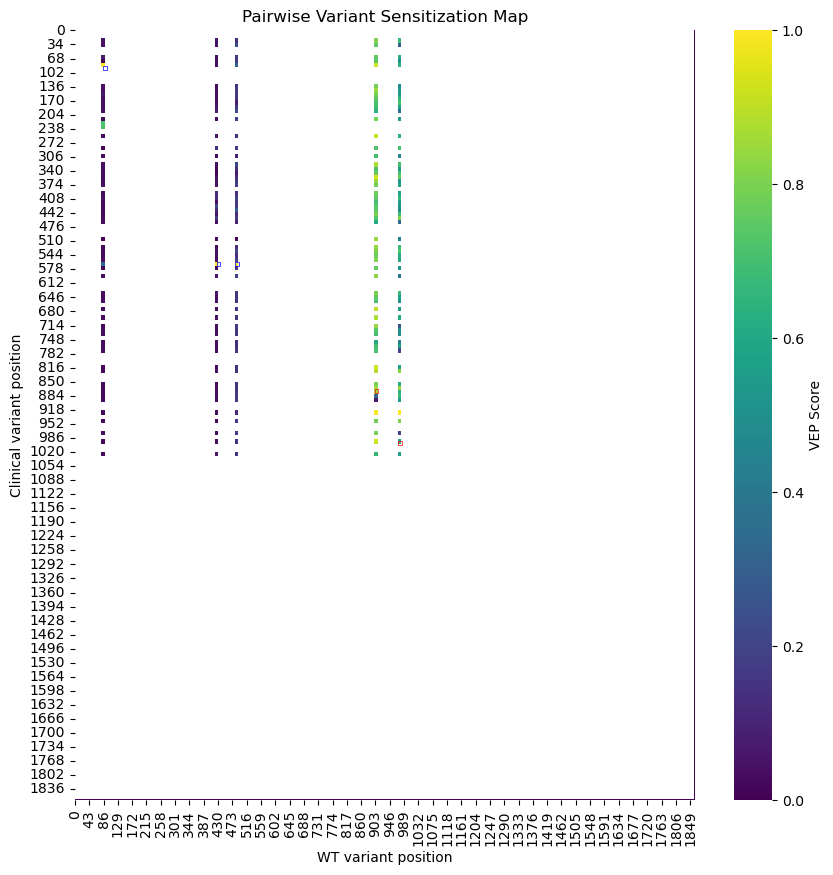

In [ ]:
# # Create empty matrix filled with zeros
# matrix_size = 1863  # Total protein length
# vep_matrix = np.zeros((matrix_size, matrix_size))
# # Fill matrix with mean VEP values
# for _, row in vep_prot.loc[vep_prot["variant"] != "REF"].iterrows():
#     # Handle NaN values in variant_position
#     if pd.isna(row['variant_position']):
#         continue
#     else:
#         i = int(row['Protein_position']) - 1  # Convert to 0-based indexing
#         j = int(row['variant_position']) - 1
#         vep_matrix[i, j] = row['VEP']  # Only fill one direction to maintain row=Protein, col=variant

# # Invert the matrix so that higher VEP scores are more red
# vep_matrix = vep_matrix*-1

# # Normalize each row to sum to 1, skipping NAs
# normalize_rows = True
# if normalize_rows:
#     row_sums = np.nansum(vep_matrix, axis=1, keepdims=True)
#     vep_matrix = np.divide(vep_matrix, row_sums, where=(row_sums!=0) & (row_sums!=np.nan))


# # Normalize the whole matrix to a scale from 0 to 1
# # vep_matrix = (vep_matrix - np.nanmin(vep_matrix)) / (np.nanmax(vep_matrix) - np.nanmin(vep_matrix))
# # # Invert the matrix
# # vep_matrix = 1 - vep_matrix

# # Log
# # vep_matrix = vep_matrix**1.05
# # vep_matrix = np.log1p(vep_matrix)


# import scipy.spatial.distance
# corr_axis = None
# if corr_axis == "x":
#     # Calculate cosine similarity along rows
#     vep_matrix = scipy.spatial.distance.cdist(vep_matrix, vep_matrix, metric='cosine')
#     vep_matrix = np.nanmax(vep_matrix) - vep_matrix
# elif corr_axis == "y":
#     # Calculate cosine similarity along columns
#     vep_matrix = scipy.spatial.distance.cdist(vep_matrix.T, vep_matrix.T, metric='cosine')
#     vep_matrix = np.nanmax(vep_matrix) - vep_matrix

 

# # Bin the matrix
# bin_size=20
# vep_matrix_binned = cf.bin_matrix(vep_matrix.copy(), bin_size=bin_size, agg_func=np.nanmax)
# n_bins = vep_matrix_binned.shape[0]
# # Invert the contact matrix
# # vep_matrix = np.log10(vep_matrix + 1e-6)
# # vep_matrix = np.nan_to_num(vep_matrix, nan=0) 


# # Plot the contact matrix
# # plt.figure(figsize=(12, 10))
# plt.imshow(vep_matrix_binned, cmap='jet')
# plt.colorbar().ax.set_ylabel("Mean VEP Score", 
#                                 rotation=270, 
#                                 va="bottom") 

# plt.title('Pairwise Variant Sensitization Map')
# plt.xlabel('WT variant position')
# plt.ylabel('Clinical variant position')

# cf.label_bins(bin_size, n_bins)

# plt.show()

full_length = 1863 


# Add sequence positions to the outlier dataframe
vep_prot = utils.variants_to_positions(vep_prot, 
                                          variant_col="variant", 
                                          position_col="variant_position")
vep_prot = utils.variants_to_positions(vep_prot, 
                                          variant_col="mutant", 
                                          position_col="mutant_position")
Xs = mc.fill_coordinates(vep_prot, full_length=full_length) 
plt.figure(figsize=(10,10))

target_size = 1863
bin_size = 10

Xs = utils.minmax_normalize(Xs, procedure=["cols"])

# Set diagonal to nan
Xs.values[np.diag_indices_from(Xs)] = np.nan

Xs_binned = cf.bin_matrix(Xs, bin_size=bin_size)
Xs_binned = cf.expand_matrix(Xs_binned, target_size=target_size)
sns.heatmap(Xs_binned, cmap='viridis', cbar_kws={'label': 'VEP Score'})
plt.title('Pairwise Variant Sensitization Map')
plt.xlabel('WT variant position')
plt.ylabel('Clinical variant position')


va.add_rectangles(xy_pairs=outlier_sig, 
                  width=10,
                  height=10,
                  xy_pairs_are_idx=True,
                  x_col="wt_position",
                  y_col="clinical_position",
                  color_col="outlier_type",
                  cmap={"high": "red", "low": "blue"} )


### Overlay sensitization map on contact map

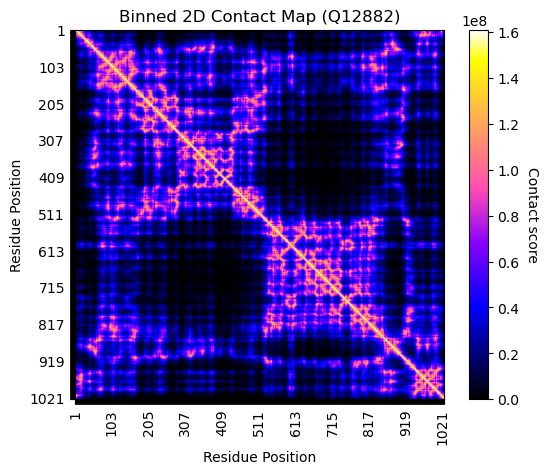

In [21]:
contact_map, contact_map_binned = cf.plot_contact_map(contact_map=contact_map, 
                    title=f"Binned 2D Contact Map ({uniprot_id})",  
                    bin_size=1, 
                    log_before_bin=False, 
                    log_after_bin=False, 
                    max_labels=10, 
                    pow=4,
                    cmap="gnuplot2",
                    agg_func=np.nanmax)

In [23]:
target_size = cf.get_ref_size(contact_map_binned)

AttributeError: 'numpy.ndarray' object has no attribute 'keys'

No target size specified, using input size 1025
Matrix already has target size 1025x1025
(1025, 1025)
Adding rectangles


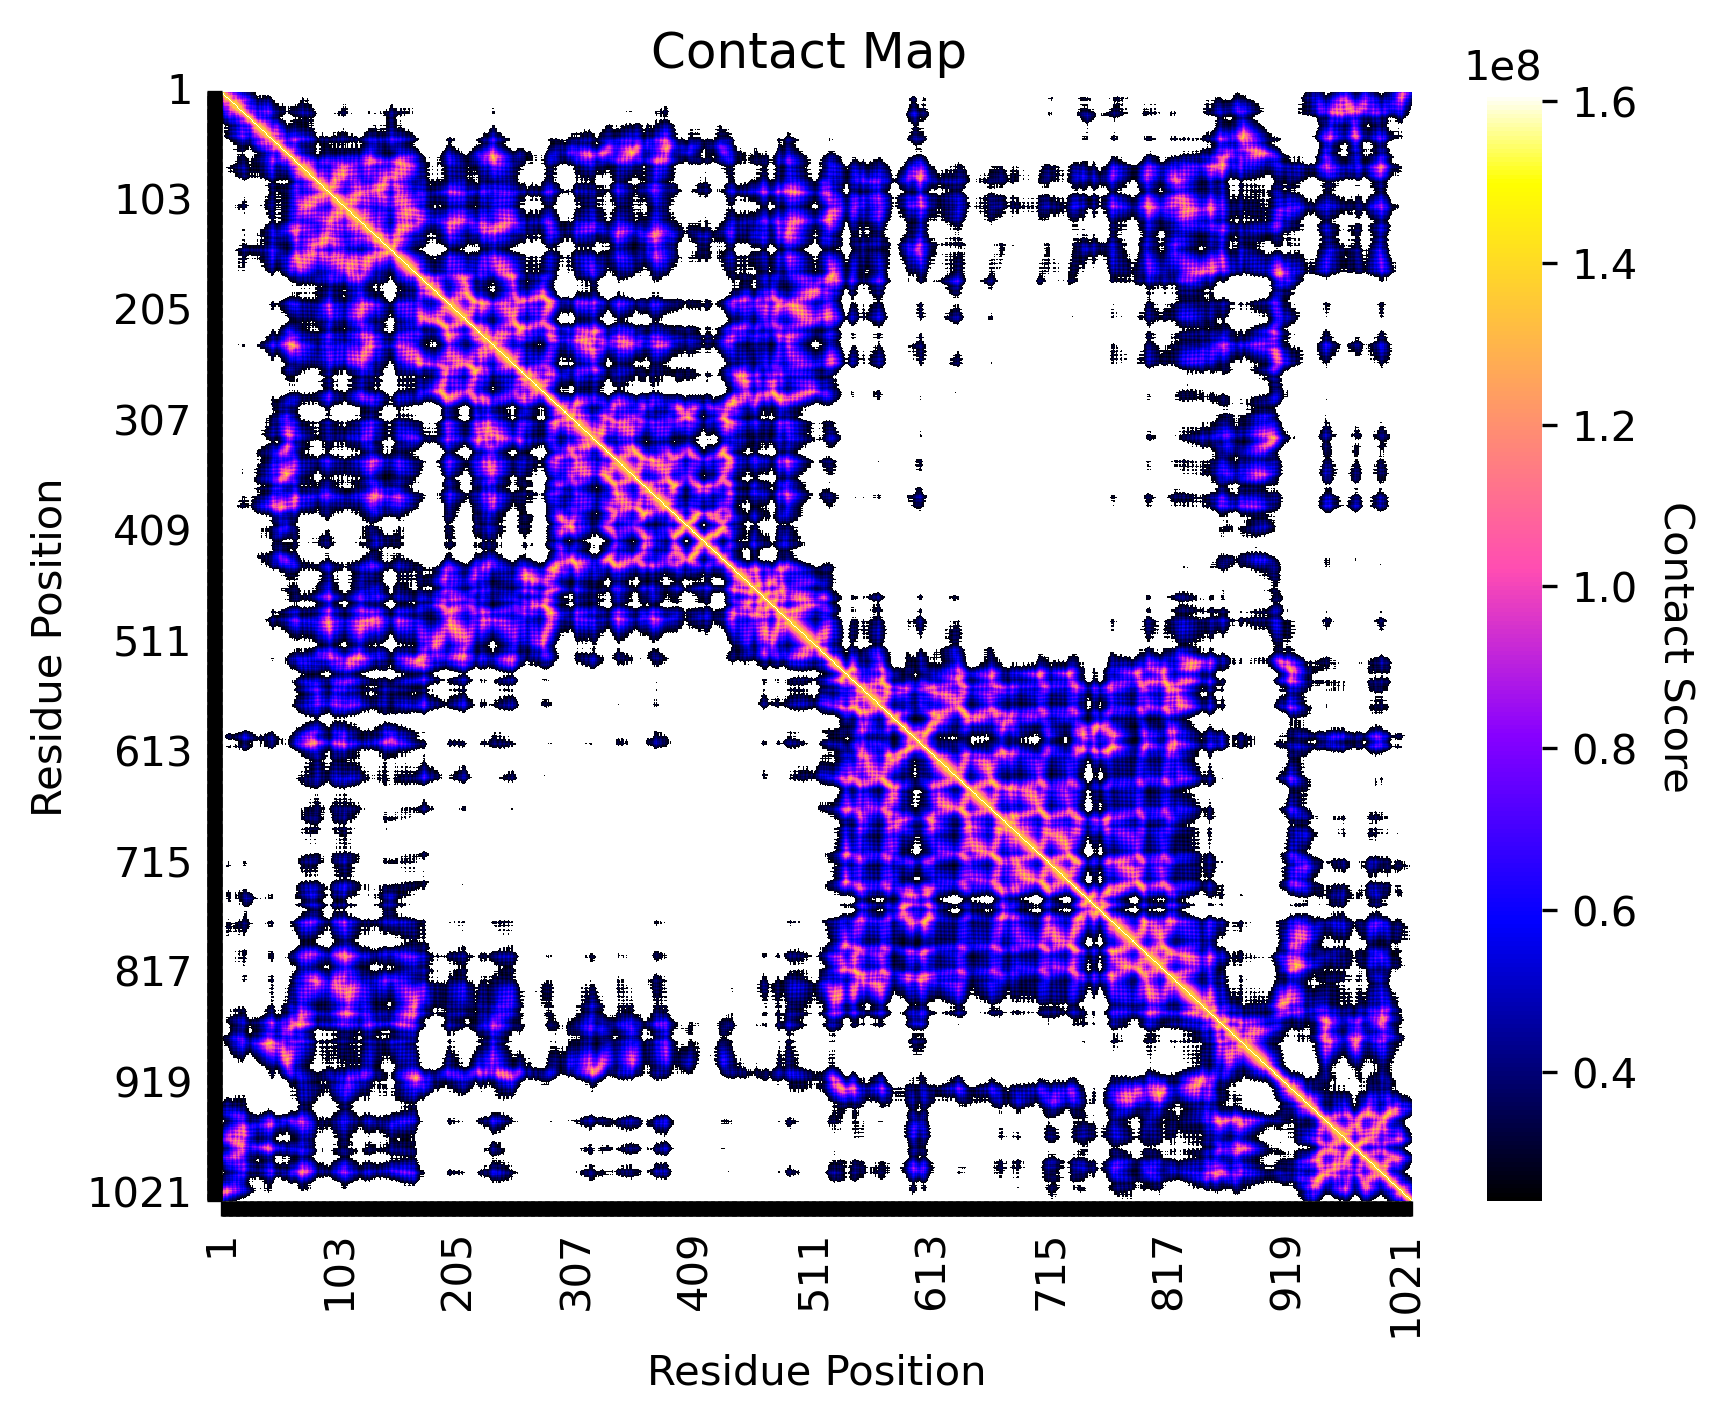

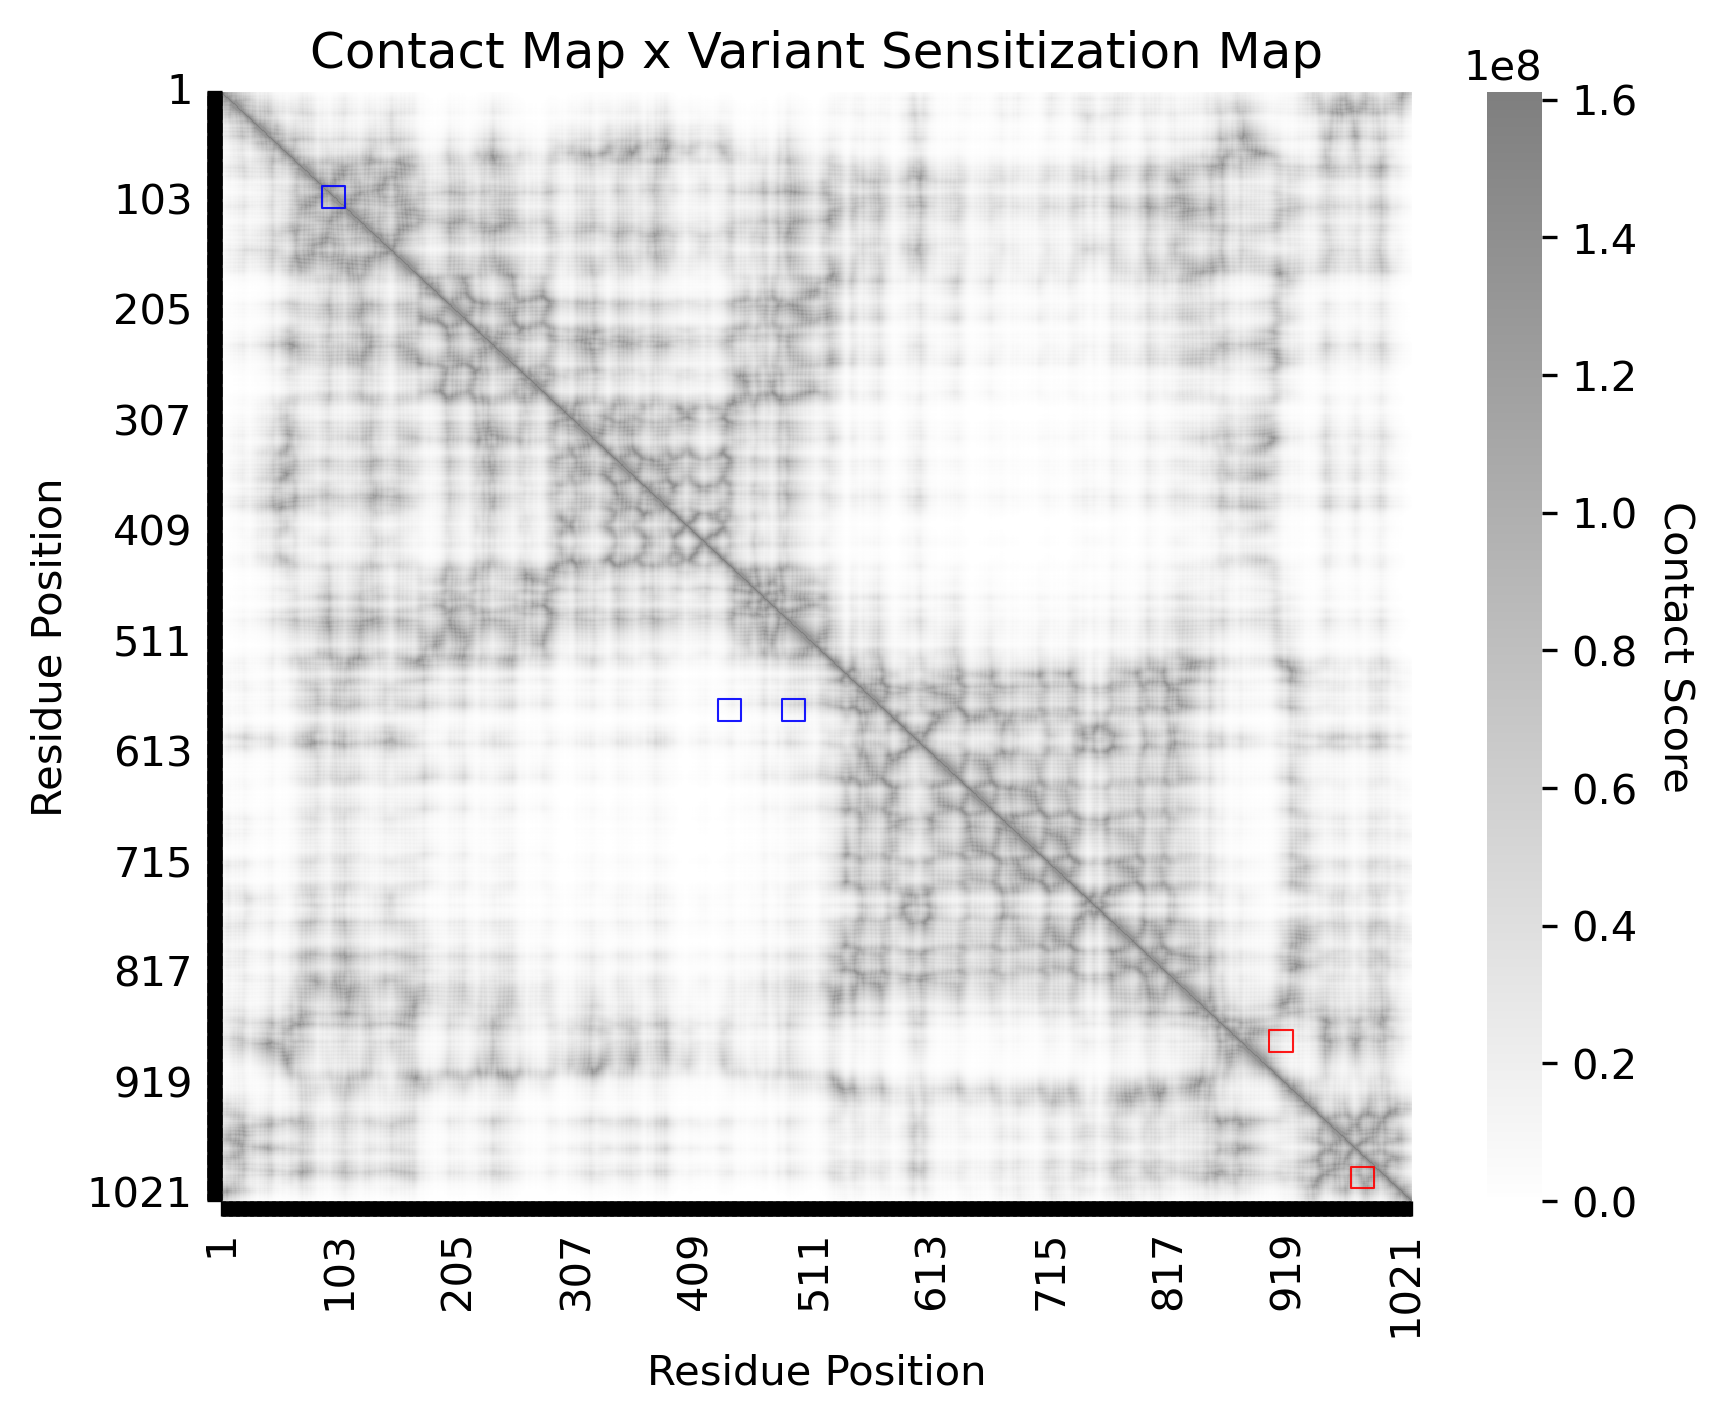

In [ ]:
plot_contact_and_sensitization_maps_out = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=contact_map_binned,
    outlier_sig=outlier_sig,
    add_rect=True,
    dpi=300,
    save_fig=False,
    save_path=None,
    cmap="gnuplot2",
    height_width=20,
    mask_color=None
)

## Test for enrichment of contacts in variant interaction maps

### Compare to outlier detection vs. ridge regression method

In [ ]:
ridge_df, model = ab.wtvariants_to_vep_linear_model(vep_df=vep_df) 

outlier_ridge_df = outlier_df.merge(ridge_df, 
                                          on=["wt_variant", "clinical_variant"], 
                                          how="inner")
outlier_ridge_df["wt_clinical_variant"] = outlier_ridge_df["wt_variant"] + ":" + outlier_ridge_df["clinical_variant"]
# outlier_interaction_df['is_sig'] = outlier_interaction_df["significant"] & (outlier_interaction_df["p_adjusted"] < 0.0001)
outlier_ridge_df["z_score_abs"] = outlier_ridge_df["z_score"].abs()
outlier_ridge_df["p_value_log10"] = np.log10(outlier_ridge_df["p_value"]+1e-10)

# sns.scatterplot(data=outlier_ridge_df, x="z_score", y="interaction_strength")

x_col = "z_score"
y_col = "interaction_strength"

import plotly.express as px
from scipy.stats import linregress
# Calculate linear regression stats
# Remove NaNs and infs for correlation
df_corr = outlier_ridge_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
slope, intercept, r_value, p_value, std_err = linregress(np.log10(df_corr[x_col].abs() + 1e-10), np.log10(df_corr[y_col].abs() + 1e-10))

r2 = r_value**2

fig = px.scatter(
    outlier_ridge_df, 
    x=x_col, 
    y=y_col, 
    color="p_value_log10",
    hover_data=["wt_variant", "clinical_variant"],
    color_continuous_scale="Purp_r",
    height=600, 
    width=600,
    # log_x=True, 
    # log_y=True,
    title=f"{x_col} vs. {y_col}<br>R²={r2:.3f}, p={p_value:.2e}",
    labels={
        x_col: "Z-score<br>(outlier detection method)",
        y_col: "Interaction strength<br>(ridge regression method)"
    }
)

fig.show()


### Get binary contact map

File /home/schilder/.cache/alphafold_db/cif/AF-P38398-F1-model_v4.cif already exists, skipping download.


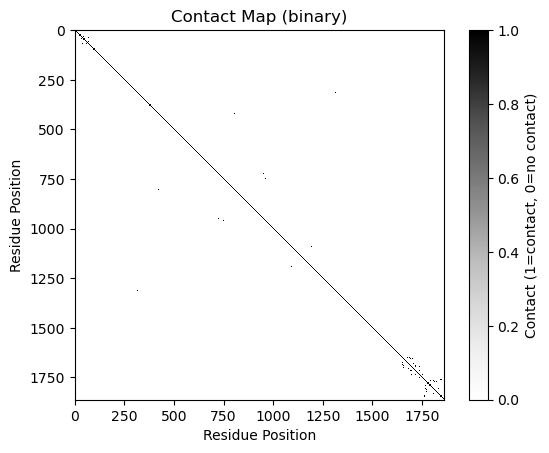

In [26]:
structure = cf.import_mmcif(protein_id = "P38398")[0]

contact_map_binary = cf.get_contact_map(structure, 
                                    max_distance=8.0, 
                                    continuous=False, 
                                    return_distance_map=False )

contact_map_binary.sum(axis=None) / contact_map_binary.size

plt.imshow(contact_map_binary, cmap="Greys", interpolation="none")
plt.title("Contact Map (binary)")
plt.xlabel("Residue Position")
plt.ylabel("Residue Position")
plt.colorbar(label="Contact (1=contact, 0=no contact)")
plt.show()

### Contact enrichment: outlier detection method

In [ ]:
Xoutliers_all = mc.fill_coordinates(outlier_df, 
                            x_id_col="wt_variant",
                            y_id_col="clinical_variant",
                            x_pos_col="wt_position",
                            y_pos_col="clinical_position",
                            value_col="z_score",
                            full_length=contact_map_binary.shape[0])  
print(Xoutliers_all.notna().sum().sum())

Xoutliers_sig = mc.fill_coordinates(outlier_sig, 
                            x_id_col="wt_variant",
                            y_id_col="clinical_variant",
                            x_pos_col="wt_position",
                            y_pos_col="clinical_position",
                            value_col="z_score",
                            full_length=contact_map_binary.shape[0])  
print(Xoutliers_sig.notna().sum().sum())

print("\nUsing total positions baseline:")
# Compute enrichment by setting the expected probability to:
# the proportion of residue-residue pairs that are contacts.
res1 = ab.run_contact_enrichment(contact_map_binary,  
                        Xoutliers_sig=Xoutliers_sig,
                        use_Xoutliers_all_non_na_baseline=False)

print("\nUsing Xoutliers_all non-NA baseline:")
# Compute enrichment by setting the expected probability to:
# the proportion of WT variant vs Clinical variant comparisons 
# (regardless of outlier significance) that are also contacts.
res2 = ab.run_contact_enrichment(contact_map_binary, 
                        Xoutliers_sig=Xoutliers_sig,
                        Xoutliers_all=Xoutliers_all, 
                        use_Xoutliers_all_non_na_baseline=True) 


17
5

Using total positions baseline:
Proportion of non-NA Xoutliers that overlap with contacts: 0.200 (1/5)
Total number of non-NA Xoutliers: 5
Total number of contacts: 9710
Using total positions baseline: 9710 positions with contacts / 3470769 total positions = 2.798e-03
Expected overlap by chance: 2.798e-03
Binomial test p-value: 1.391e-02
Fold enrichment of contact overlap among non-NA Xoutliers: 71.49x

Using Xoutliers_all non-NA baseline:
Proportion of non-NA Xoutliers that overlap with contacts: 0.200 (1/5)
Total number of non-NA Xoutliers: 5
Total number of contacts: 9710
Using Xoutliers_all non-NA baseline: 1 positions with contacts
Proportion of non-NA Xoutliers_all that overlap with contacts: 0.059 (1/5)
Expected overlap by chance: 5.882e-02
Binomial test p-value: 2.615e-01
Fold enrichment of contact overlap among non-NA Xoutliers: 3.40x


In [ ]:
outlier_df['z_score_abs'] = outlier_df['z_score'].abs()
results = ab.compute_enrichment_vs_threshold(
    outlier_df=outlier_df,
    contact_map_binary=contact_map_binary, 
    num_thresholds=50,
    linear_sampling=True,  
    interaction_col="z_score_abs"
)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:01<00:00, 26.81it/s]


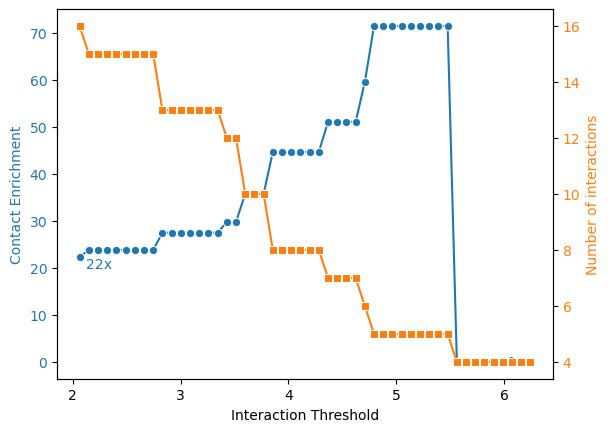

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Interaction Threshold', ylabel='Contact Enrichment'>,
 <Axes: xlabel='interaction_threshold', ylabel='Number of interactions'>)

In [ ]:
ab.plot_enrichment_vs_interactions(results)

### Contact enrichment: ridge regression method

In [ ]:
# print("\nUsing Xoutliers_all non-NA baseline:")
# # Compute enrichment by setting the expected probability to:
# # the proportion of WT variant vs Clinical variant comparisons 
# # (regardless of outlier significance) that are also contacts.
# res_interaction2 = ab.run_contact_enrichment(contact_map_binary, 
#                                             Xoutliers_sig=Xinteraction_sig,
#                                             Xoutliers_all=Xoutliers_all, 
#                                             use_Xoutliers_all_non_na_baseline=True) 

results2 = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

100%|██████████| 50/50 [00:01<00:00, 26.33it/s]


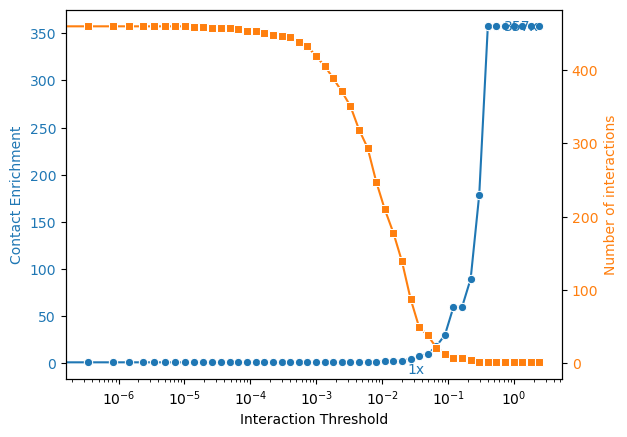

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Interaction Threshold', ylabel='Contact Enrichment'>,
 <Axes: xlabel='interaction_threshold', ylabel='Number of interactions'>)

In [ ]:
ab.plot_enrichment_vs_interactions(results2, log_x_axis=True)

## Validate sensitization maps with DMS

**Sources**:

**BRCA1 RING domain DMS**

From:  
https://www.sciencedirect.com/science/article/pii/S0002929722002105

**BRCA1 missense mutations HDR assay**

From:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC3906639/


**Megascale single- and double-mutation DMS**

From: 
> Tsuboyama, K., Dauparas, J., Chen, J. et al. Mega-scale experimental analysis of protein folding stability in biology and design. Nature 620, 434–444 (2023). https://doi.org/10.1038/s41586-023-06328-6

Download Megascale data from [Zenodo](https://zenodo.org/records/7992926)

`wget https://zenodo.org/records/7992926/files/Processed_K50_dG_datasets.zip?download=1`

In [ ]:
dbxrefs = up.get_dbxrefs(protein_id="P38398")
pdb_ids = set(sorted(dbxrefs.loc[dbxrefs["db"]=="PDB"].id.tolist()))
print(len(pdb_ids))

31


In [19]:
import os
import pandas as pd 
Double_DMS_list = pd.read_csv(os.path.expanduser("~/projects/data/Processed_K50_dG_datasets/Double_DMS_list.csv.gz"))
Double_DMS_list

,K50_corr,dg_corr,recon_corr,NA_num,max_ep_dG,wt_ep_dG,double_mut_name
0,0.982029,0.984488,0.990647,4,1.828974,NaN,1A0N.pdb_hnet0
1,0.958524,0.965766,0.919933,0,1.856412,0.967539,1CSQ.pdb_dmutv5_28V:63V
2,0.762928,0.838220,0.923095,258,0.598982,NaN,1E0L.pdb_dmutv5_9T:23N
3,0.717876,0.738602,0.886551,35,0.941192,0.941192,1E0L.pdb_hnet0
4,0.989747,0.979541,0.988915,0,1.337935,0.158870,1E6H.pdb_dmutv5_40W:51F
...,...,...,...,...,...,...,...
720,0.718511,0.900221,0.936381,6,0.916234,0.303979,HHH_rd4_0125.pdb_hnet0
721,0.942046,0.961573,0.989812,5,0.548975,0.292364,HHH_rd4_0395.pdb_hnet0
722,0.672105,0.824247,0.852548,6,0.848578,0.402097,HHH_rd4_0518.pdb_hnet0
723,0.929486,0.927692,0.981938,12,0.958619,0.958619,HHH_rd4_0676.pdb_hnet0


In [66]:
Double_DMS_list.loc[Double_DMS_list["double_mut_name"].str.contains("|".join(pdb_ids))]

,K50_corr,dg_corr,recon_corr,NA_num,max_ep_dG,wt_ep_dG,double_mut_name


In [27]:
dms1 = pd.read_csv(os.path.expanduser("~/projects/data/Processed_K50_dG_datasets/Tsuboyama2023_Dataset1_20230416.csv.gz"))
dms1

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML
0,1A32.pdb,TCTGCGGGTGGCTCTCCAGAAGTTCAGATTGCGATCCTGACCGAAC...,0.240062,0.259872,0.218340,0.041532,0.069827,-1.781164,2.696992,2.723847,2.667541,0.056306,-0.764121,-0.740229,-0.781839,0.041611,0.048051,-2.730495,2.620790,2.653094,2.596824,0.056270,2.674476,2.723361,2.644279,0.079082,0.2400615540197126,-0.7641209993449366
1,1A32.pdb_A45D,TCTGCGGGTGGTTCTCCGGAAGTTCAGATCGCTATTCTGACCGAAC...,0.245272,0.271181,0.237714,0.033467,0.046275,-1.728073,2.632435,2.667598,2.622177,0.045421,-0.712336,-0.682819,-0.722734,0.039916,0.040527,-2.580149,2.487671,2.527694,2.473564,0.054130,2.558410,2.595347,2.516665,0.078682,0.2452717737233243,-0.7123364923356303
2,1A32.pdb_A45E,TCTGCGGGTGGTTCTCCGGAAGTTCAGATCGCTATTCTGACCGAAC...,0.411134,0.421462,0.402358,0.019104,0.045609,-1.726210,2.854924,2.868932,2.843022,0.025910,-0.545468,-0.526458,-0.569871,0.043413,0.051709,-2.631064,2.782184,2.807850,2.749225,0.058626,2.830464,2.879223,2.791301,0.087922,0.4111336742937279,-0.545467769242733
3,1A32.pdb_A45F,TCCGCTGGCGGTTCTCCGGAAGTTCAGATCGCTATTCTGACCGAAC...,0.038186,0.051789,-0.001474,0.053263,0.072121,-1.793375,2.439442,2.457941,2.385471,0.072470,-1.137910,-1.108316,-1.194216,0.085901,0.054003,-2.765160,2.159766,2.200242,2.082575,0.117667,2.280177,2.351299,2.212888,0.138411,0.0381855701102482,-1.1379101516061252
4,1A32.pdb_A45G,TCTGCTGGTGGCTCTCCGGAAGTTCAGATCGCTATTCTGACCGAAC...,-0.017184,0.013252,-0.031242,0.044494,0.052017,-1.765509,2.326206,2.367694,2.307027,0.060667,-0.975749,-0.960248,-0.999105,0.038857,0.038534,-2.700348,2.292774,2.313889,2.260935,0.052955,2.349356,2.404530,2.269762,0.134769,-0.0171837522091489,-0.9757493546746832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1841280,5GHB.pdb_I68C,TCCGCGGGTGGTCACATCAACCTGAAAGTTGCGGGTCAGGACGGTT...,-0.659227,-0.592633,-0.713220,0.120587,0.063869,-1.675883,1.299455,1.397173,1.219067,0.178106,-2.320076,-2.208109,-2.403438,0.195328,0.084167,-2.768383,0.343328,0.561563,0.159775,0.401787,0.799442,0.896299,0.721957,0.174342,-0.6592273716286323,-2.32007634084457
1841281,5GHB.pdb_D69C,TCTGCTGGCGGTCACATCAACCTGAAAGTTGCGGGTCAGGACGGTT...,1.526104,1.553159,1.500452,0.052707,0.064731,-1.690861,4.361019,4.401617,4.322799,0.078818,0.267503,0.287781,0.229525,0.058256,0.088664,-2.777843,4.077375,4.105002,4.025692,0.079311,4.309125,4.351921,4.272543,0.079379,1.5261042575493224,0.2675031199165091
1841282,5GHB.pdb_V70C,TCTGCTGGCGGTCACATTAACCTGAAAGTTGCGGGTCAGGACGGCT...,0.189385,0.213863,0.152034,0.061828,0.102480,-1.678700,2.489757,2.523049,2.438925,0.084124,-0.972439,-0.814098,-1.100147,0.286049,0.143640,-2.766491,2.387179,2.601802,2.213221,0.388582,2.555101,2.643876,2.396862,0.247014,0.1893847673240727,-0.9724388178041864
1841283,5GHB.pdb_F71C,TCCGCTGGCGGCCATATCAACCTGAAAGTTGCGGGTCAGGACGGTT...,1.406698,1.424117,1.375079,0.049039,0.073401,-1.670525,4.157925,4.183294,4.112098,0.071196,0.077789,0.089868,0.048222,0.041645,0.068112,-2.763729,3.800988,3.817341,3.760982,0.056359,4.049197,4.084906,4.015010,0.069896,1.4066979508059534,0.0777885370976122


In [68]:
dms1.loc[dms1["name"].str.contains("|".join(pdb_ids))]
 

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML
499140,set11_N1JNX9.117-46,TCCGCTGGTGGCTCCGCGGGCGGTTCCGCGGGTGGTTCTGCGGGTG...,-0.017922,-0.008259,-0.030625,0.022365,0.082483,-0.655576,0.701511,0.718261,0.679321,0.038940,-1.462514,-1.414958,-1.525056,0.110098,0.034082,-1.851206,0.214635,0.318313,0.065434,0.252880,0.462701,0.542862,0.417863,0.124998,-0.0179216732836494,-1.4625143416992945
500322,set12_A0A1F4JLU7.152-94,TCTGCTGGTGGTTCTGCGGGCGGTTCCGCGGGTGGCTCCGCTTACA...,-0.430406,-0.404734,-0.447279,0.042545,0.058229,-1.148805,0.836989,0.879134,0.808969,0.070165,-1.642467,-1.540622,-1.728386,0.187763,0.073965,-2.449142,0.979027,1.137076,0.840307,0.296769,0.888184,1.020706,0.815662,0.205044,-0.4304060665627838,-1.6424673760640778


In [69]:
dms2 = pd.read_csv(os.path.expanduser("~/projects/data/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv.gz"))
dms2

/tmp/ipykernel_2156966/3246311425.py:1: DtypeWarning: Columns (30,31,36) have mixed types. Specify dtype option on import or set low_memory=False.
  dms2 = pd.read_csv(os.path.expanduser("~/projects/data/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv.gz"))


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name
0,EA|run2_0325_0005.pdb,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.227105,1.255092,1.197643,0.057449,0.063626,-0.997071,2.998711,3.038485,2.956981,0.081505,1.213568,1.233374,1.185022,0.048351,0.085196,-1.213423,3.342631,3.374493,3.297191,0.077301,3.332126,3.386173,3.272414,0.113759,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2271050771597385,1.2135682995736825,3.3321258839433834,0.01719762915616707,False,NaN
1,EA|run2_0325_0005.pdb_wtm,TCCGCGGGTGGTTCCGCTGGCGGTTCTGCGGGCGGTGACGAAGTTA...,1.297559,1.381800,1.243835,0.137965,0.092264,-0.997071,3.099109,3.220506,3.022470,0.198035,1.220181,1.249626,1.190686,0.058940,0.109459,-1.213423,3.353237,3.400859,3.306163,0.094696,3.399832,3.466193,3.336566,0.129626,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2975591020191513,1.2201805304541726,3.3998316632160224,0.08490340842880606,False,NaN
2,EA|run2_0325_0005.pdb_wte,TCCGCTGGTGGCTCTGCGGGCGGTTCTGCTGGTGGCGACGAAGTTA...,1.262708,1.314787,1.239876,0.074911,0.092305,-0.997071,3.049332,3.123805,3.016844,0.106962,1.169472,1.212553,1.144460,0.068093,0.129405,-1.213423,3.272663,3.341005,3.233516,0.107489,3.315782,3.384876,3.248385,0.136491,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2627076164958364,1.169472475788951,3.315782210420261,0.0008539556330444675,False,NaN
3,EA|run2_0325_0005.pdb_wty,TCCGCTGGTGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.244782,1.314467,1.195005,0.119462,0.074537,-0.997071,3.023818,3.123346,2.953250,0.170096,1.154317,1.207086,1.117204,0.089882,0.084201,-1.213423,3.248899,3.332264,3.191261,0.141004,3.272933,3.345357,3.194881,0.150476,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2447822859698547,1.1543165166325822,3.272933265369934,-0.04199498941728219,False,NaN
4,EA|run2_0325_0005.pdb_wth,TCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCG...,0.998142,1.134508,0.723845,0.410663,0.315576,-1.010140,2.694897,2.885558,2.314727,0.570831,0.657357,0.713460,0.598176,0.115284,0.210897,-1.198612,2.497476,2.577213,2.413736,0.163477,2.570242,2.730598,2.228088,0.502510,SAGGSAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELAR...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,0.9981417661631856,0.6573573370630326,2.570241917260095,-0.7446863375271211,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776293,9AME.pdb_dmutv5_32I:40L_I32P:L40I,TCCGCGGGTGGCTCTGCTGGCGGCAACCAGGCGTCTGTTGTTGCGA...,-1.307630,-1.215993,-1.452696,0.236704,0.066656,-1.370583,-1.077540,-0.492711,-25.000000,24.507289,-2.396317,-2.253618,-2.533013,0.279395,0.035279,-2.384390,-15.000000,-0.606611,-25.000000,24.393389,-2.850140,-2.199486,-4.066487,1.867001,SAGGSAGGNQASVVANQLIPINTALTLVMMRSEVVTPVGPPAEDIP...,NQASVVANQLIPINTALTLVMMRSEVVTPVGPPAEDIPRIVGMQVN...,I32P:L40I,9AME.pdb,23,-1.3076297070150713,-2.396316795278767,<-1,-,-,9AME.pdb_dmutv5_32I:40L
776294,9AME.pdb_dmutv5_32I:40L_I32P:L40W,TCCGCGGGTGGTTCTGCGGGCGGTAATCAGGCGTCTGTTGTTGCGA...,-1.428440,-1.346840,-1.516532,0.169692,0.029102,-1.361836,-15.000000,-1.942130,-25.000000,23.057870,-2.474485,-2.393724,-2.550663,0.156939,0.046641,-2

In [70]:
dms2.loc[dms2["name"].str.contains("|".join(pdb_ids))]


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name


## Create averaged matrix

Contact map 90th percentile: 118.12671661376953
VEP matrix 90th percentile: 0.7882186110685288
High contact: 302574
High VEP: 347000
High both: 23295


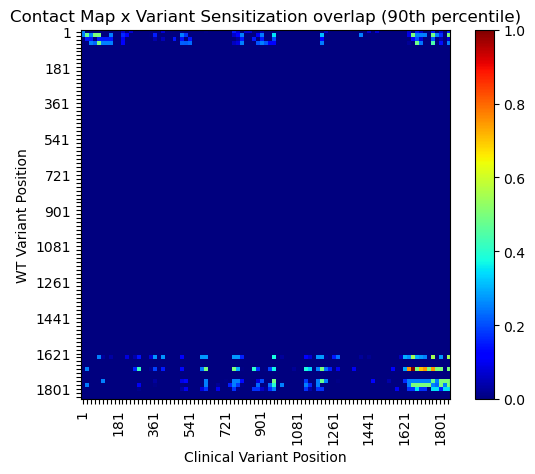

In [36]:
# Calculate 95th percentile for each matrix

method = "linear"

# Set diagonals to nan
# np.fill_diagonal(contact_map, np.nan)
# np.fill_diagonal(vep_matrix, np.nan)


pctl = [90,90]
# Create a copy of contact_map and set diagonal to nan

pctl1 = pctl[0]
# contact_map_no_diag = contact_map.copy()
# np.fill_diagonal(contact_map_no_diag, np.nan)
# contact_map_95th = np.percentile(np.nan_to_num(contact_map_no_diag, nan=np.nanmedian(contact_map_no_diag)), q=pctl1, method=method)
# print(f"Contact map {pctl1}th percentile:", contact_map_95th)

# Filter based on confidence category and ensure alignment with contact map
high_confidence_mask = plddt_df.set_index("residue").reindex(range(contact_map.shape[0]))["confidence_category"].isin(["high", "very_high"]).values 
# Apply mask to matrices
contact_map_no_diag = contact_map.copy()
np.fill_diagonal(contact_map_no_diag, np.nan)
# Set low confidence residues to nan
contact_map_no_diag[~high_confidence_mask] = np.nan
# Find 95th percentile
contact_map_95th = np.percentile(np.nan_to_num(contact_map_no_diag, nan=np.nanmedian(contact_map_no_diag)), q=pctl1, method=method)
print(f"Contact map {pctl1}th percentile:", contact_map_95th)




# Create a copy of vep_matrix and set diagonal to nan
pctl2=pctl[1]
# Xs_no_diag = cf.expand_matrix(Xs_binned, target_size=1863)
# np.fill_diagonal(Xs_no_diag, np.nan)
Xs_no_diag = Xs_binned.copy()
Xs_95th = np.percentile(np.nan_to_num(Xs_no_diag, nan=np.nanmedian(Xs_no_diag)), q=pctl2, method=method)
print(f"VEP matrix {pctl2}th percentile:", Xs_95th)

# Find indices where both matrices exceed their 95th percentile
high_contact = contact_map_no_diag > contact_map_95th
high_vep = Xs_no_diag > Xs_95th
high_both = np.logical_and(high_contact, high_vep)

print(f"High contact: {high_contact.sum()}")
print(f"High VEP: {high_vep.sum()}")
print(f"High both: {high_both.sum()}")



bin_size=20
high_both_binned = cf.bin_matrix(high_both, bin_size=bin_size, agg_func=np.nanmean) 
n_bins = high_both_binned.shape[0]
# high_both_binned = np.log10(high_both_binned+1e-6)

plt.imshow(high_both_binned, cmap='jet')
cf.label_bins(bin_size, n_bins)
plt.colorbar() 
plt.xlabel("Clinical Variant Position")
plt.ylabel("WT Variant Position")
plt.title(f"Contact Map x Variant Sensitization overlap ({pctl1}th percentile)")
plt.show()





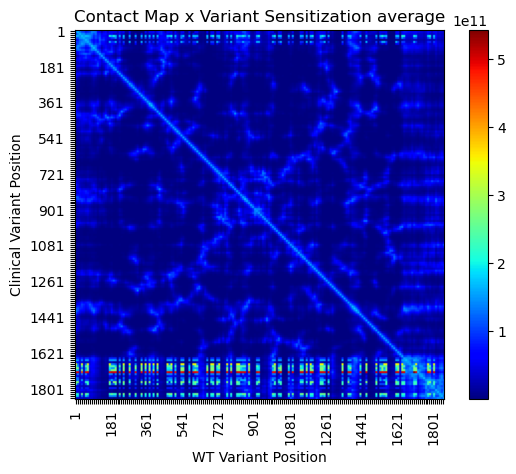

Where both matrices exceed 95th percentile: 24311


In [168]:
# np.fill_diagonal(high_both, False)

avg_matrix = cf.average_matrices([contact_map_no_diag, 
                                    Xs_no_diag
                                       ], 
                                      weights=[1, 15], 
                                      normalize_scale=False, 
                                      normalize_rows=[False, False],
                                      use_max=True
                                      )
 
avg_matrix = avg_matrix**5
# Set values below 95th percentile to 0
# vep_matrix_no_diag[~high_both] = np.nan
# contact_map_no_diag[~high_both] = np.nan

norm_rows=False
if norm_rows:
    row_sums = np.nansum(avg_matrix, axis=1, keepdims=True)
    avg_matrix = np.divide(avg_matrix, row_sums, 
                                where=(row_sums!=0) & (row_sums!=np.nan))

bin_size=10
avg_matrix_binned = cf.bin_matrix(avg_matrix, bin_size=bin_size, agg_func=np.nanmean) 
n_bins = avg_matrix_binned.shape[0]

plt.imshow(avg_matrix_binned, cmap='jet')
cf.label_bins(bin_size, n_bins)
plt.colorbar()
plt.xlabel("WT Variant Position")
plt.ylabel("Clinical Variant Position")
plt.title(f"Contact Map x Variant Sensitization average")
plt.show()
 

# Print the results
print(f"Where both matrices exceed {pctl1}th percentile:", high_both.sum())
 


## UniProt Annotations

In [ ]:
dbxrefs = up.get_dbxrefs(protein_id="P38398")
dbxrefs 

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


,dbxref,db,id
0,AGR:HGNC:1100,AGR,HGNC:1100
1,AlphaFoldDB:P38398,AlphaFoldDB,P38398
2,Antibodypedia:4527,Antibodypedia,4527
3,BMRB:P38398,BMRB,P38398
4,BRENDA:2.3.2.27,BRENDA,2.3.2.27
...,...,...,...
583,VEuPathDB:HostDB:ENSG00000012048,VEuPathDB,HostDB:ENSG00000012048
584,eggNOG:KOG4362,eggNOG,KOG4362
585,iPTMnet:P38398,iPTMnet,P38398
586,jPOST:P38398,jPOST,P38398


In [ ]:
seqs = up.get_seqs("P38398")
seqs

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


[Seq('MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQ...SHY')]

In [ ]:
features_df = up.get_features("P38398")
features_df.head()

,id,type,start,end,description,evidence,original,variation,ref,length
0,PRO_0000055830,chain,0,1863,Breast cancer type 1 susceptibility protein,NaN,NaN,NaN,NaN,1863
1,<unknown id>,domain,1641,1736,BRCT 1,2,NaN,NaN,NaN,95
2,<unknown id>,domain,1755,1855,BRCT 2,2,NaN,NaN,NaN,100
3,<unknown id>,zinc finger region,23,65,RING-type,3,NaN,NaN,NaN,42
4,<unknown id>,region of interest,229,270,Disordered,4,NaN,NaN,NaN,41


In [ ]:
# Transform VEP data from haplotype- to sample-level
vep_prot = vep_df[vep_df['protein'] == "NP_009225.1"].merge(haps_to_samples, on=["haplotype"], how="left")

rm_cols = ["sample","haplotype","is_ref","Super Population","Population","Gender","VEP"]
mutant_df = vep_prot.drop(columns=rm_cols).drop_duplicates()
# mutant_df = mutant_df.groupby([col for col in mutant_df.columns if col != 'VEP']).agg({"VEP":"mean"}).reset_index()
mutant_df["mutant_cluster"] = mutant_df["mutant"].map(variant_to_cluster)
# Count unique variants per cluster
cluster_variant_counts = mutant_df.groupby('mutant_cluster')['mutant'].nunique().reset_index()
cluster_variant_counts.columns = ['mutant_cluster', 'mutants_per_cluster']

# Merge with original dataframe
mutant_df = mutant_df.merge(cluster_variant_counts, on='mutant_cluster', how='left')

mutant_df


,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,scoring_strategy,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,ENST_haplosaurus,mutant_cluster,mutants_per_cluster
0,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,ENST00000357654,2,6
1,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,ENST00000357654,57,11
2,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,NaN,NaN,NaN,NaN,NaN,0.791910,NaN,5,benign,ENST00000357654,60,64
3,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045704,55632,G,A,.,PASS,55632,17:43045704,A,672,NM_007294.4,Transcript,missense_variant,5679,5566,1856,P/S,Ccc/Tcc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5566C>T,NP_009225.1:p.Pro1856Ser,-,NaN,0.00002,70299,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Heredi...,NC_000017.11:g.43045704G>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357274,NaN,ClinGen:CA003722,NaN,N

Cluster 68 has 11 unique variants


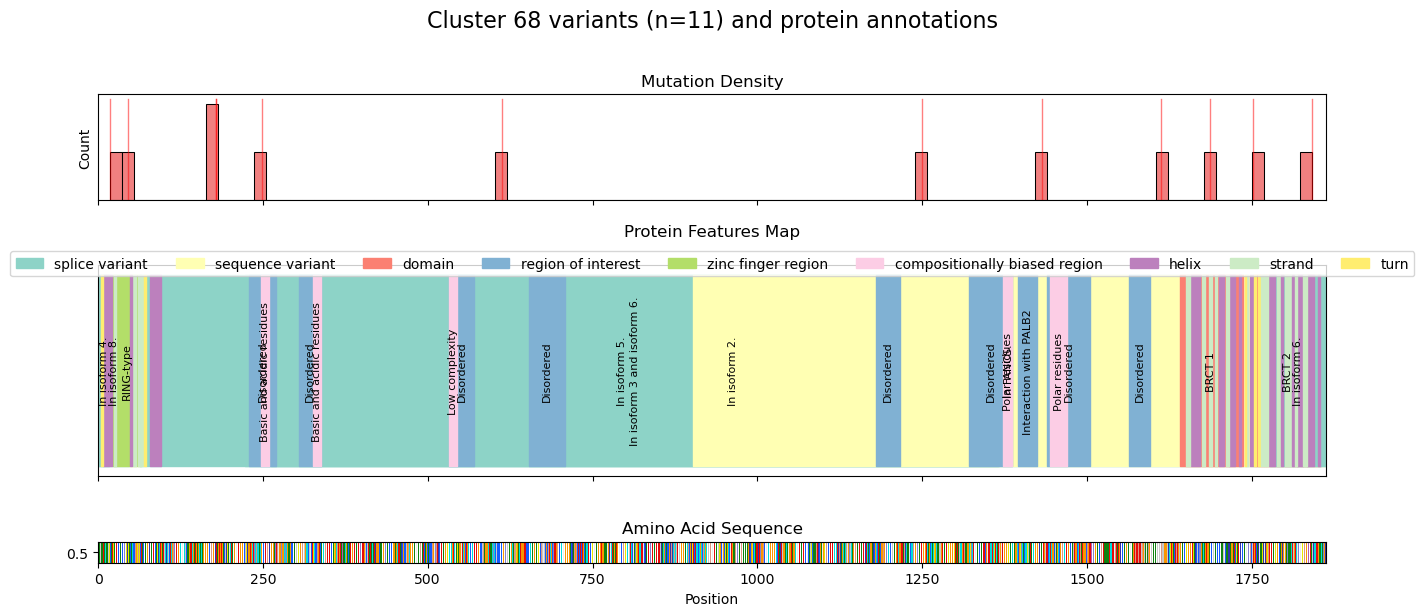

In [ ]:

include_types = None
min_length = 2
exclude_types = ["chain",]
max_len = features_df.loc[features_df["type"] == "chain", "end"][0]


mutant_df = mutant_df.sort_values('mutants_per_cluster', ascending=False)
cluster_id = mutant_df["mutant_cluster"].unique()[9]
muts = mutant_df.loc[mutant_df["mutant_cluster"] == cluster_id]
# Merge annotation data from EnsemblVEP
# muts = muts.merge(cv_annot, on="mutant", how="left")



print(f"Cluster {cluster_id} has {muts['mutants_per_cluster'].iloc[0]} unique variants")

seq = str(seqs[0])

plot_df = features_df.copy()
plot_df.sort_values("length",ascending=False, inplace=True)

if include_types is not None:
    plot_df = plot_df[plot_df["type"].str.contains("|".join(include_types))]

if min_length is not None:
    plot_df = plot_df[plot_df["length"] >= min_length]

if exclude_types is not None:
    plot_df = plot_df[~plot_df["type"].str.contains("|".join(exclude_types))]

# Create figure with three subplots
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(15, 6), height_ratios=[0.5, 1, 0.1], sharex=True)

# Add overall title
fig.suptitle(f'Cluster {cluster_id} variants (n={muts["mutants_per_cluster"].iloc[0]}) and protein annotations', fontsize=16, y=1.02)

# Plot mutations and KDE on top subplot
sns.histplot(data=muts, 
             x='Protein_position', ax=ax0, fill=True, alpha=0.3, bins=100, fc='lightcoral')
y_max = ax0.get_ylim()[1]  # Get the maximum y value once
for pos in muts['Protein_position']:
    ax0.plot([pos, pos], [0, y_max], color='red', alpha=0.5, linewidth=1)
ax0.set_yticks([])
ax0.set_title('Mutation Density')

# Plot features on middle subplot
colors = plt.cm.Set3(np.linspace(0, 1, len(plot_df['type'].unique())))
type_to_color = dict(zip(plot_df['type'].unique(), colors))
for _, feat in plot_df.iterrows():
    if pd.notna(feat['start']) and pd.notna(feat['end']):
        ax1.fill_between([feat['start'], feat['end']], 
                        [-0.1, -0.1], [0.1, 0.1],
                        color=type_to_color[feat['type']],
                        alpha=1,
                        label=feat['type'] if feat['type'] not in ax1.get_legend_handles_labels()[1] else "")
        
        # Add description label if it exists
        if 'description' in feat and pd.notna(feat['description']):
            mid_point = (feat['start'] + feat['end']) / 2
            ax1.text(mid_point, 0, feat['description'],
                    rotation=90, ha='center', va='center',
                    fontsize=8)

# Define amino acid colors based on properties
aa_colors = {
    'A': '#C8C8C8',  # Alanine - Gray
    'C': '#E6E600',  # Cysteine - Yellow
    'D': '#E60A0A',  # Aspartic acid - Red
    'E': '#E60A0A',  # Glutamic acid - Red
    'F': '#3232AA',  # Phenylalanine - Blue
    'G': '#EBEBEB',  # Glycine - Light gray
    'H': '#8282D2',  # Histidine - Light blue
    'I': '#0F820F',  # Isoleucine - Green
    'K': '#145AFF',  # Lysine - Blue
    'L': '#0F820F',  # Leucine - Green
    'M': '#E6E600',  # Methionine - Yellow
    'N': '#00DCDC',  # Asparagine - Cyan
    'P': '#DC9682',  # Proline - Pink
    'Q': '#00DCDC',  # Glutamine - Cyan
    'R': '#145AFF',  # Arginine - Blue
    'S': '#FA9600',  # Serine - Orange
    'T': '#FA9600',  # Threonine - Orange
    'V': '#0F820F',  # Valine - Green
    'W': '#B45AB4',  # Tryptophan - Purple
    'Y': '#3232AA'   # Tyrosine - Blue
}

# Plot amino acids on bottom subplot
if seq:
    for i, aa in enumerate(seq):
        ax2.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 1, 
                                  facecolor=aa_colors.get(aa, '#FFFFFF'),
                                  linewidth=0.1))
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.5])
    ax2.set_title('Amino Acid Sequence', y=1)
else:
    print("No sequence found")
    ax2.plot([0, max_len], [0.5, 0.5], 'k-', alpha=0.5, linewidth=5, label='Sequence')

# Configure plot appearance
ax1.set_title('Protein Features Map', y=1.1)
ax1.set_yticks([])
ax1.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=10)
ax1.set_xlim(0, max_len)

ax2.set_xlabel('Position')
ax2.set_xlim(0, max_len)

plt.tight_layout()

In [ ]:
import pyranges as pr

# Convert mutations to pyranges format
mut_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(muts),
    starts=muts["Protein_position"] - 1,  # Convert to 0-based
    ends=muts["Protein_position"],
    strands=muts["STRAND"],
)
mut_ranges.mutant = muts["mutant"]  # Use mutant instead of Name

# Convert features to pyranges format
feature_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(features_df),
    starts=features_df["start"],
    ends=features_df["end"],
    strands=["+"] * len(features_df)
)
feature_ranges.feature_type = features_df["type"]  # Changed Name to feature_type

# Find overlaps between mutations and features
overlaps = mut_ranges.join(feature_ranges, suffix="_feature")

# Convert back to pandas DataFrame
overlap_df = overlaps.df
overlap_df

# Count overlaps per feature type
# feature_counts = overlap_df.groupby("feature_type")["feature_type"].count().reset_index()
# feature_counts.columns = ["feature_type", "overlap_count"]

# print("\nOverlap counts by feature type:")
# print(feature_counts.sort_values("overlap_count", ascending=False))

# # Add overlap information to muts DataFrame
# muts["overlapping_features"] = muts["mutant"].map(
#     overlap_df.groupby("mutant")["feature_type"].agg(list).to_dict()
# )


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


,Chromosome,Start,End,Strand,mutant,Start_feature,End_feature,Strand_feature,feature_type
0,chr1,44,45,NaN,K45Q,0,1863,+,chain
1,chr1,44,45,NaN,K45Q,0,47,+,splice variant
2,chr1,44,45,NaN,K45Q,23,65,+,zinc finger region
3,chr1,44,45,NaN,K45Q,44,45,+,sequence variant
4,chr1,17,18,NaN,M18T,0,1863,+,chain
5,chr1,17,18,NaN,M18T,0,47,+,splice variant
6,chr1,17,18,NaN,M18T,7,21,+,helix
7,chr1,17,18,NaN,M18T,17,18,+,sequence variant
8,chr1,178,179,NaN,Y179C,0,1863,+,chain
9,chr1,178,179,NaN,Y179C,63,1863,+,splice variant


In [ ]:
features_df["type"].value_counts()

type
sequence variant                 170
modified residue                  30
mutagenesis site                  27
strand                            19
helix                             15
cross-link                        13
region of interest                 9
splice variant                     8
sequence conflict                  8
compositionally biased region      5
turn                               5
domain                             2
zinc finger region                 1
chain                              1
Name: count, dtype: int64

In [ ]:
# spliceai_cols = [x for x in muts.columns if x.startswith("SpliceAI_pred_D")]

# annot_cols  = [
#     #### CADD ####
#     "CADD_PHRED","CADD_RAW",

#     #### REVEL ####
#     "REVEL",

#     #### MaveDB ####
#    "MaveDB_score_mean", 
#    "MaveDB_score_abs_mean",
# #    "MaveDB_score_min",
# #    "MaveDB_score_max",


#     #### EVE ####
#     "EVE_SCORE",
    
#     #### ClinPred ####
#     "ClinPred",

#     #### RF ####
#     "rf_score",

#     #### AdaScore ####
#     "ada_score",

#     #### MaxEntScan ####
#     'MaxEntScan_diff',
    
#     #### LOEUF ####
#     "LOEUF",
    
#     #### AlphaMissense ####
#     "am_pathogenicity",

#     ### SpliceAI ####
#     *spliceai_cols,
#     #### OpenTargets ####
# #    "OpenTargets_l2g",


#     #### Allele Frequences ####
#     "gnomADe_AF","gnomADg_AF","AF_TGP",
#     "AllOfUs_gvs_all_af", "AllOfUs_gvs_max_af",

#     # "MOTIF_SCORE_CHANGE",

#     #### pHaplo ####
#     # "pHaplo" => "Probability of haploinsufficiency (deletion intolerance) of the affected gene",
#     # "pTriplo" => "Probability of triplosensitivity (duplication intolerance) of the affected gene"
#     "pHaplo",
#     "pTriplo",


#     ### Conservation ####
#     "SIFT_score",
#     "PolyPhen_score",
#     ]


#  # Create heatmap with protein position on x-axis and other features on y-axis
#  plt.figure(figsize=(15, 8))
#  sns.heatmap(cv_annot.loc[cv_annot["SYMBOL"] == "BRCA1" ,["Protein_position"]+[x for x in annot_cols if x in cv_annot.columns]].set_index("Protein_position").T
#             cmap='RdBu_r',
#             center=0,
#             annot=True,
#             fmt='.2f',
#             square=True)
#  plt.title('Feature Values by Protein Position')
#  plt.xlabel('Protein Position')
#  plt.ylabel('Features')
#  plt.tight_layout()

## GWAS validation

### Coignard2021

In [139]:
##### Top 10000 variants from Coignard2021 #####
## Not useful because they filtered out all variants that were in BRCA1

# gwas_file="/home/schilder/projects/data/GWAS/Coignard2021/regressionResultsAfterReimputation_BRCA1_10000.txt.gz"

# gwas = pd.read_csv(gwas_file, sep=" ")
# gwas.head()
# brca1_coords ="chr17:41196312-41277381" # They use hg37 coordinates in this GWAS, so we will too

# gwas.loc[(gwas["Position"]>=int(brca1_coords.split(":")[1].split("-")[0])) & 
#          (gwas["Position"]<=int(brca1_coords.split(":")[1].split("-")[1]))]


In [22]:
gwas_file = "/home/schilder/projects/data/GWAS/Coignard2021/cimba_onco_icogs_brca1_combined_results.zip"

import polars as pl
from zipfile import ZipFile

gwas_chr = pl.read_csv(
    ZipFile(gwas_file).read(os.path.basename(gwas_file).replace(".zip", ".txt")),
    separator="\t",
    infer_schema_length=10000,  # Increase schema inference length
    null_values=["NULL"],  # Add NULL to null values
    schema_overrides={  # Specify dtypes for problematic columns
        "icogs2_bc_info": pl.Float64,
        "icogs2_bc_freq": pl.Float64,
        "icogs2_bc_effect": pl.Float64,
        "icogs2_bc_se": pl.Float64,
        "icogs2_bc_pval": pl.Float64
    }
).filter(pl.col("chr")==17)

print(gwas_chr.shape)
gwas_chr.head()

(456811, 38)


rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction
str,i64,i64,str,f64,f64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,str
"""17:52:C:A""",17,52,"""17_52_C_A""",0.000541,0.664775,0,0,"""C""","""A""",0.721138,1.213085,0.193167,0.541178,0.350419,0.437139,-0.827505,0.886192,"""C""","""A""",0.225281,-3.789136,2.671984,0.225281,-2.771221,4.359519,"""a""","""c""",0.0005,0.1932,0.5412,0.7211,"""+?""",0.0005,-0.8275,0.8862,0.3504,"""-?"""
"""rs145615430:56:C:T""",17,56,"""17_56_C_T""",0.001,0.323611,0,0,"""C""","""T""",0.820707,0.89661,-0.109135,0.481541,0.523686,0.621026,-0.476383,0.747064,"""C""","""T""",0.229661,1.396688,1.420701,0.229661,-1.893447,2.155891,"""t""","""c""",0.001,-0.1091,0.4815,0.8207,"""-?""",0.001,-0.4764,0.7471,0.5237,"""-?"""
"""rs148170422:78:G:C""",17,78,"""17_78_G_C""",0.001,0.243554,0,0,"""G""","""C""",0.186139,0.387825,-0.9472,0.716443,0.195097,0.230769,-1.466337,1.131741,"""G""","""C""",0.113934,-3.025613,2.424038,0.113934,0.329529,3.636421,null,null,null,null,null,null,null,null,null,null,null,null
"""rs62053745:828:T:C""",17,828,"""17_828_T_C""",0.783234,0.966918,0,0,"""T""","""C""",0.534691,1.015588,0.015467,0.024913,0.485857,1.027975,0.027591,0.03959,"""T""","""C""",0.407974,0.121292,0.083104,0.407974,-0.083174,0.123594,"""t""","""c""",0.2164,-0.0242,0.0239,0.3107,"""--""",0.2164,-0.0173,0.0377,0.6467,"""-+"""
"""rs9747082:834:G:A""",17,834,"""17_834_G_A""",0.846528,0.953082,0,0,"""G""","""A""",0.867914,0.995236,-0.004776,0.028716,0.119026,1.073717,0.071126,0.045627,"""G""","""A""",0.447624,0.098814,0.088035,0.447624,-0.119045,0.130955,"""a""","""g""",0.8459,0.0052,0.0273,0.8493,"""-+""",0.8459,0.0505,0.0431,0.2408,"""+-"""


In [100]:
brca1_coords ="chr17:41196312-41277381" # They use hg37 coordinates in this GWAS, so we will too
gwas_brca1 = gwas_chr.filter(
    (pl.col("position")>=int(brca1_coords.split(":")[1].split("-")[0])) &
    (pl.col("position")<=int(brca1_coords.split(":")[1].split("-")[1]))
).to_pandas() 

print(gwas_brca1.shape)
gwas_brca1.head()

(383, 38)


,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++


In [101]:
# Convert coordinates from hg19 to hg38 using pyliftover
import src.pyliftover as plift

gwas_brca1 = plift.liftover(gwas_brca1, 
                            from_build='hg19', 
                            to_build='hg38', 
                            chrom_col='chr', 
                            position_cols=['position'], 
                            force=True)
gwas_brca1

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,43044346
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,43044351
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,43044391
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,43044745
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,43044804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,rs377617416:41276764:TTTTTG:T,17,41276764,17_41276764_TTTTTG_T,0.001000,0.292181,0,0,TTTTTG,T,0.778045,1.173781,0.160230,0.568458,0.451471,2.022455,0.704312,0.935386,TTTTTG,T,0.255055,-0.395183,0.948052,0.255055,0.634204,1.325604,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,43124747
379,17:41277109:TCCCTCGCGACCTACAAACTGCCC:T,17,41277109,17_41277109_TCCCTCGCGACCTACAAACTGCCC_T,0.001000,0.357545,0,0,TCCCTCGCGACCTACAAACTGCCC,T,0.027655,0.268856,-1.313579,0.596500,0.215936,3.183575,1.158005,0.935832,TCCCTCGCGACCTACAAACTGCCC,T,0.538584,0.487958,0.890254,0.538584,1.283738,1.252522,t,tccctcgcgacctacaaactgccc,0.0013,-0.7554,0.4955,0.12740,-+,0.0014,1.2030,0.7497,0.1086,++,43125092
380,rs799905:41277187:G:C,17,41277187,17_41277187_G_C,0.336402,0.994377,0,0,G,C,0.401445,0.982050,-0.018113,0.021587,0.687469,1.013930,0.013834,0.034388,G,C,0.994117,-0.102707,0.049498,0.994117,0.002390,0.073303,c,g,0.3362,-0.0316,0.0198,0.10990,--,0.3361,0.0118,0.0311,0.7054,++,43125170
381,rs273898672:41277277:G:A,17,41277277,17_41277277_G_A,0.001000,0.770209,0,0,G,A,0.618723,1.176321,0.162392,0.326311,0.466181,1.431425,0.358670,0.492201,G,A,0.458022,-1.064996,1.532646,0.458022,0.989916,2.110159,a,g,0.0010,0.1092,0.3192,0.73230,+-,0.0010,0.3912,0.4793,0.4144,++,43125260


In [103]:
gwas_brca1 = utils.add_variant_name(gwas_brca1, chrom_col="chr", start_col="position_hg38", end_col=None, ref_col="onco_baseline", alt_col="onco_effect", alias="site", force=True)
gwas_brca1["HGVSg"] =  "NC_000017.11" +  ":g." + gwas_brca1["position_hg38"].astype(str) + gwas_brca1["onco_baseline"] + ">" + gwas_brca1["onco_effect"]
# Handle HGVS deletion notation for multi-base deletions
# https://hgvs-nomenclature.org/stable/recommendations/DNA/delins/
mask = (gwas_brca1["onco_baseline"].str.len() > 1) & (gwas_brca1["onco_effect"].str.len() == 1)
gwas_brca1.loc[mask, "HGVSg"] = (
    "NC_000017.11:g." + 
    gwas_brca1.loc[mask, "position_hg38"].astype(str) + "_" +
    (gwas_brca1.loc[mask, "position_hg38"] + gwas_brca1.loc[mask, "onco_baseline"].str.len() - 1).astype(str) +
    "del" + gwas_brca1.loc[mask, "onco_baseline"]
)

gwas_brca1

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,43044346,chr17:43044346-43044347_C_T,NC_000017.11:g.43044346C>T
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,43044351,chr17:43044351-43044352_C_T,NC_000017.11:g.43044351C>T
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,43044391,chr17:43044391-43044392_G_A,NC_000017.11:g.43044391G>A
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,43044745,chr17:43044745-43044746_C_T,NC_000017.11:g.43044745C>T
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,43044804,chr17:43044804-43044806_CT_C,NC_000017.11:g.43044804_43044805delCT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,rs377617416:41276764:TTTTTG:T,17,41276764,17_41276764_TTTTTG_T,0.001000,0.292181,0,0,TTTTTG,T,0.778045,1.173781,0.160230,0.568458,0.451471,2.022455,0.704312,0.935386,TTTTTG,T,0.255055,-0.395183,0.948052,0.255055,0.634204,1.325604,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,43124747,chr17:43124747-43124753_TTTTTG_T,NC_000017.11:g.43124747_43124752delTTTTTG
379,17:41277109:TCCCTCGCGACCTACAAACTGCCC:T,17,41277109,17_41277109_TCCCTCGCGACCTACAAACTGCCC_T,0.001000,0.357545,0,0,TCCCTCGCGACCTACAAACTGCCC,T,0.027655,0.268856,-1.313579,0.596500,0.215936,3.183575,1.158005,0.935832,TCCCTCGCGACCTACAAACTGCCC,T,0.538584,0.487958,0.890254,0.538584,1.283738,1.252522,t,tccctcgcgacctacaaactgccc,0.0013,-0.7554,0.4955,0.12740,-+,0.0014,1.2030,0.7497,0.1086,++,43125092,chr17:43125092-43125116_TCCCTCGCGACCTACAAACTGC...,NC_000017.11:g.43125092_43125115delTCCCTCGCGAC...
380,rs799905:41277187:G:C,17,41277187,17_41277187_G_C,0.336402,0.994377,0,0,G,C,0.401445,0.982050,-0.018113,0.021587,0.687469,1.013930,0.013834,0.034388,G,C,0.994117,-0.102707,0.049498,0.994117,0.002390,0.073303,c,g,0.3362,-0.0316,0.0198,0.10990,--,0.3361,0.0118,0.0311,0.7054,++,43125170,chr17:43125170-43125171_G_C,NC_000017.11:g.43125170G>C
381,rs273898672:41277277:G:A,17,41277277,17_41277277_G_A,0.001000,0.770209,0,0,G,A,0.618723,1.176321,0.162392,0.326311,0.466181,1.431425,0.358670,0.492201,G,A,0.458022,-1.064996,1.532646,0.458022,0.989916,2.110159,a,g,0.0010,0.1092,0.3192,0.73230,+-,0.0010,0.3912,0.4793,0.4144,++,43125260,chr17:43125260-43125261_G_A,NC_000017.11:g.43125260G>A


#### Translate GWAS HGVSg to HGVSp

In [ ]:
import src.mutalyzer as mz

hgvs_norm = mz.normalize_hgvs_ids(gwas_brca1["HGVSg"].tolist()) 

Normalizing HGVS IDs:   0%|          | 0/383 [00:00<?, ?it/s]

Normalizing HGVS IDs:  21%|██        | 81/383 [00:16<01:01,  4.88it/s]


KeyboardInterrupt: 

In [107]:
hgvs_norm["HGVSc"] = hgvs_norm["c.reference"] + hgvs_norm["c.description"].str.split(":").str[1]
hgvs_norm

,input_description,normalized_description,c.description,c.reference,c.tag,HGVSc
0,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11(NM_001408458.1):c.*1332G>A,NM_001408458.1,nan,NM_001408458.1c.*1332G>A
1,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11(NM_001407967.1):c.*1332G>A,NM_001407967.1,nan,NM_001407967.1c.*1332G>A
2,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11(NM_001407959.1):c.*1332G>A,NM_001407959.1,nan,NM_001407959.1c.*1332G>A
3,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11(NM_001407931.1):c.*1332G>A,NM_001407931.1,nan,NM_001407931.1c.*1332G>A
4,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11(NM_001407747.1):c.*1332G>A,NM_001407747.1,nan,NM_001407747.1c.*1332G>A
...,...,...,...,...,...,...
368,NC_000017.11:g.43125337G>A,NC_000017.11:g.43125337G>A,NC_000017.11(NM_007298.3):c.-1241C>T,NM_007298.3,nan,NM_007298.3c.-1241C>T
369,NC_000017.11:g.43125337G>A,NC_000017.11:g.43125337G>A,NC_000017.11(NM_007294.3):c.-86C>T,NM_007294.3,nan,NM_007294.3c.-86C>T
370,NC_000017.11:g.43125337G>A,NC_000017.11:g.43125337G>A,NC_000017.11(NM_007299.3):c.-80C>T,NM_007299.3,nan,NM_007299.3c.-80C>T
371,NC_000017.11:g.43125337G>A,NC_000017.11:g.43125337G>A,NC_000017.11(NM_007297.3):c.-167C>T,NM_007297.3,nan,NM_007297.3c.-167C>T


In [109]:
gwas_brca1_hgvs = gwas_brca1.merge(hgvs_norm.loc[hgvs_norm["c.reference"] == "NM_007294.4"], 
                              left_on="HGVSg", 
                              right_on="input_description", 
                              how="inner")

gwas_brca1_hgvs

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg,input_description,normalized_description,c.description,c.reference,c.tag,HGVSc
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,43044346,chr17:43044346-43044347_C_T,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11:g.43044346C>T,NC_000017.11(NM_007294.4):c.*1332G>A,NM_007294.4,"{'id': 'NM_007294.4', 'details': 'MANE Select'}",NM_007294.4c.*1332G>A
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,43044351,chr17:43044351-43044352_C_T,NC_000017.11:g.43044351C>T,NC_000017.11:g.43044351C>T,NC_000017.11:g.43044351C>T,NC_000017.11(NM_007294.4):c.*1327G>A,NM_007294.4,"{'id': 'NM_007294.4', 'details': 'MANE Select'}",NM_007294.4c.*1327G>A
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,43044391,chr17:43044391-43044392_G_A,NC_000017.11:g.43044391G>A,NC_000017.11:g.43044391G>A,NC_000017.11:g.43044391G>A,NC_000017.11(NM_007294.4):c.*1287C>T,NM_007294.4,"{'id': 'NM_007294.4', 'details': 'MANE Select'}",NM_007294.4c.*1287C>T
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,43044745,chr17:43044745-43044746_C_T,NC_000017.11:g.43044745C>T,NC_000017.11:g.43044745C>T,NC_000017.11:g.43044745C>T,NC_000017.11(NM_007294.4):c.*933G>A,NM_007294.4,"{'id': 'NM_007294.4', 'details': 'MANE Select'}",NM_007294.4c.*933G>A
4,rs138782023:41196945:T:C,17,41196945,17_41196945_T_C,0.004000,0.494477,0,0,T,C,0.208822,1.356942,0.305234,0.242863,0.725431,0.873684,-0.135037,0.384491,T,C,0.470201,0.739292,0.591550,0.470201,-0.958944,0.869487,t,c,0.9962,-0.3678,0.2247,0.10160,--,0.9963,0.2698,0.3516,0.4429,++,43044928,chr17:43044928-43044929_T_C,NC_000017.11:g.43044928T>C,NC_000017.11:g.43044928T>C,NC_000017.11:g.43044928T>C,NC_000017.11(NM_007294.4):c.*750A>G,NM_007294.4,"{'id': 'NM_007294.4', 'details': 'MANE Select'}",NM_007294.4c.*750A>G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,rs8176077:41276348:T:C,17,41276348,17_41276348_T_C,0.324108,0.994918,0,0,T,C,0.158694,0.969722,-0.030746,0.021814,0.735664,1.011814,0.011744,0.034787,T,C,0.996117,-0.114515,0.049906,0.996117,0.016246,0.073932,t,c,0.6763,0.0442,0.0200,0.02707,++,0.6763,-0.0126,0.0315,0.6899,--,43124331,chr17:43124331-43124332_T_C,NC_000017.11:g.43124331T>C,NC_000017.11:g.43124331T>C,NC_000017.11:g.43124331T>C,NC_000017.11(NM_007294.4):c.-19-216A>G,NM_007294.4,"{'id': 'NM_007294.4', 'details': 'MANE Select'}",NM_007294.4c.-19-216A>G
344,chr17_41276757_C_T,17,41276757,17_41276757_C_T,0.000918,1.000000,1,2,C,T,0.062917,0.558814,-0.581938,0.3129

In [110]:
force=True
if 'vep_prot' not in globals() or force:
    vep_prot = vep_df[vep_df['protein'] == 'NP_009225.1'].merge(haps_df, on=["ENST","haplotype"], how="left")

# Add site info for clinical variants (mutant)
# HGVSc amd HGVSp for clinical variants are already in the vep_prot dataframe 
vep_prot = utils.add_variant_name(vep_prot, 
                                    alias="cv_site", 
                                    chrom_col="#CHROM",
                                    start_col="POS",
                                    end_col=None,
                                    ref_col="REF",
                                    alt_col="ALT")
vep_prot.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC,variant,cv_site
0,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.639376,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,None,NaN,None,None,None,None,NaN,NaN,0.632517,NaN,5,likely_benign,BRCA1,1028R>H,chr17:43045690-43045691_G_T
1,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-1.005851,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,None,None,None,NaN,NaN,-0.490676,NaN,5,benign,BRCA1,1028R>H,chr17:43045694-43045695_G_C
2,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.775333,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,None,None,None,NaN,NaN,0.791910,NaN,5,benign,BRCA1,1028R>H,chr17:43045698-43045699_T_G
3,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.626421,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045704,55632,G,A,.,PASS,55632,17:43045704,A,672,NM_007294.4,Transcript,missense_variant,5679,5566,1856,P/S,Ccc/Tcc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5566C>T,NP_009225.1:p.Pro1856Ser,-,NaN,0.00002,70299,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Heredi...,NC_000017.11:

### Backtranslate HGVSp to HGVSc for WT variants

In [ ]:
# Create HGVSp col for WT variants
outlier_df = mz.add_hgvsp(outlier_df,
                        variant_col="wt_variant",
                        position_col="wt_position",
                        ref_col="wt_REF",
                        alt_col="wt_ALT",
                        protein_col="protein",
                        wt_HGVSp_col="wt_HGVSp")
# vep_prot = mz.add_hgvsp(vep_prot,
#                         variant_col="variant",
#                         position_col="wt_p.position",
#                         ref_col="wt_p.REF",
#                         alt_col="wt_p.ALT",
#                         protein_col="protein",
#                         wt_HGVSp_col="wt_HGVSp")

## Backtranslate HGVSp to HGVSc for WT variants
hgvsp_ids = outlier_df['wt_HGVSp'].dropna().unique()
backtranslated_df = mz.backtranslate_hgvsp_ids(hgvsp_ids, add_prefix="wt_")
 
# Add backtranslated HGVSc to vep_prot
outlier_df = outlier_df.merge(backtranslated_df, on="wt_HGVSp", how="left")
outlier_df.head() 

Backtranslating variants:   0%|          | 0/95 [00:00<?, ?it/s]

Backtranslating variants: 100%|██████████| 95/95 [03:07<00:00,  1.97s/it]


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC,variant,cv_site,wt_p.position,wt_p.REF,wt_p.ALT,wt_HGVSp,wt_HGVSc,wt_c.position,wt_c.REF,wt_c.ALT,wt_site,wt_variation_feature
0,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.639376,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,None,NaN,None,None,None,None,NaN,NaN,0.632517,NaN,5,likely_benign,BRCA1,1028R>H,chr17:43045690-43045691_G_T,1028.0,R,H,NP_009225.1:p.Arg1028His,NM_007294.4:c.3083G>A,3083.0,G,A,chr17:3083.0-3084_G_A,rs80357459
1,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-1.005851,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,None,None,None,NaN,NaN,-0.490676,NaN,5,benign,BRCA1,1028R>H,chr17:43045694-43045695_G_C,1028.0,R,H,NP_009225.1:p.Arg1028His,NM_007294.4:c.3083G>A,3083.0,G,A,chr17:3083.0-3084_G_A,rs80357459
2,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.775333,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,None,None,None,NaN,NaN,0.791910,NaN,5,benign,BRCA1,1028R>H,chr17:43045698-43045699_T_G,1028.0,R,H,NP_009225.1:p.Arg1028His,NM_007294.4:c.3083G>A,3083.0,G,A,chr17:3083.0-3084_G_A,rs80357459
3,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.626421,masked-marginals,False,esm2_

In [184]:
outlier_df

,clinical_variant,wt_variant,value,outlier_type,z_score,p_value,p_adjusted,significant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT,protein,REF,ALT,wt_HGVSp,wt_HGVSc,wt_c.position,wt_c.REF,wt_c.ALT
0,A1843P,1783M>T,0.000000,low,-9.149170,0.000000,0.000000,True,1783,M,T,1843,P,P,NP_009225.1,M,T,NP_009225.1:p.Met1783Thr,NM_007294.4:c.5348T>C,5348.0,T,C
1,Y1853S,616delS,1.000000,high,8.717383,0.000000,0.000000,True,616,S,,1853,S,S,NP_009225.1,S,,NaN,NaN,NaN,NaN,NaN
2,E1250K,1249T>S,0.000000,low,-9.429221,0.000000,0.000000,True,1249,T,S,1250,K,K,NP_009225.1,T,S,NP_009225.1:p.Thr1249Ser,NM_007294.4:c.3746C>G,3746.0,C,G
3,E1250K,1249T>S,0.000000,low,-9.429221,0.000000,0.000000,True,1249,T,S,1250,K,K,NP_009225.1,T,S,NP_009225.1:p.Thr1249Ser,NM_007294.4:c.3745A>T,3745.0,A,T
4,T37K,59S>L,0.000000,low,-9.261422,0.000000,0.000000,True,59,S,L,37,K,K,NP_009225.1,S,L,NP_009225.1:p.Ser59Leu,NM_007294.4:c.176C>T,176.0,C,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,N656Y,179Y>C,0.890223,high,2.001794,0.045307,0.045419,True,179,Y,C,656,Y,Y,NP_009225.1,Y,C,NP_009225.1:p.Tyr179Cys,NM_007294.4:c.536A>G,536.0,A,G
1994,N564H,616delS,1.000000,high,2.001379,0.045352,0.045430,True,616,S,,564,H,H,NP_009225.1,S,,NaN,NaN,NaN,NaN,NaN
1995,N473S,616delS,0.509035,low,-2.001170,0.045374,0.045430,True,616,S,,473,S,S,NP_009225.1,S,,NaN,NaN,NaN,NaN,NaN
1996,S264N,1389S>N,0.048293,low,-2.000767,0.045418,0.045445,True,1389,S,N,264,N,N,NP_009225.1,S,N,NP_009225.1:p.Ser1389Asn,NM_007294.4:c.4166G>A,4166.0,G,A


In [185]:
# vep_prot = utils.add_variant_name(outlier_df, 
#                                     alias="wt_site", 
#                                     chrom_col="#CHROM",
#                                     start_col="wt_c.position",
#                                     end_col=None,
#                                     ref_col="wt_c.REF",
#                                     alt_col="wt_c.ALT", 
#                                     force=True)
# vep_prot.head()

In [186]:
cds_diffs

,wt_ENST,wt_variation_feature,wt_variation_feature_id,wt_c.diff,wt_c.diff_pos,wt_c.REF,wt_c.ALT,wt_HGVSc
0,ENST00000357654,rs1799949,959569763.0,2082C>T,2082,C,T,NM_007294.4:c.2082C>T
1,ENST00000357654,rs16940,959538411.0,2311T>C,2311,T,C,NM_007294.4:c.2311T>C
2,ENST00000357654,rs799917,959554491.0,2612C>T,2612,C,T,NM_007294.4:c.2612C>T
3,ENST00000357654,rs16941,959538412.0,3113A>G,3113,A,G,NM_007294.4:c.3113A>G
4,ENST00000357654,rs16942,959538413.0,3548A>G,3548,A,G,NM_007294.4:c.3548A>G
...,...,...,...,...,...,...,...,...
607,ENST00000357654,rs80357464,960113518.0,995G>A,995,G,A,NM_007294.4:c.995G>A
621,ENST00000357654,rs564757581,962597295.0,4679G>T,4679,G,T,NM_007294.4:c.4679G>T
623,ENST00000357654,rs55914168,959866233.0,2351C>T,2351,C,T,NM_007294.4:c.2351C>T
624,ENST00000357654,rs191872612,960946723.0,683T>A,683,T,A,NM_007294.4:c.683T>A


In [187]:
if "wt_variation_feature" not in outlier_df.columns:
    cds_diffs =  hs.get_haplotype_diffs(haplotypes,
                                        tx_ids=["ENST00000357654"],
                                        key='cds_haplotypes')
    cds_diffs.rename(columns={"diff":"c.diff"}, inplace=True)
    cds_diffs = cds_diffs.drop(columns=["haplotype"]).drop_duplicates()
    cds_diffs = utils.variants_to_positions(cds_diffs,
                                            variant_col="c.diff",
                                            position_col="c.diff_pos",
                                            ref_col="c.REF",
                                            alt_col="c.ALT") 
    # cds_diffs["HGVSc"] = cds_diffs["ENST"] + ":c." + cds_diffs["c.diff_pos"].astype(str) + cds_diffs["c.REF"] + ">" + cds_diffs["c.ALT"] 
    cds_diffs["HGVSc"] = "NM_007294.4"+ ":c." + cds_diffs["c.diff_pos"].astype(str) + cds_diffs["c.REF"] + ">" + cds_diffs["c.ALT"] 
    cds_diffs = cds_diffs.add_prefix("wt_") 
    outlier_df = outlier_df.merge(cds_diffs[["wt_variation_feature","wt_HGVSc"]], on="wt_HGVSc", how="inner")

outlier_df.head()

Extracting haplotype diffs:   0%|          | 0/1 [00:00<?, ?it/s]

634 diffs from 1 cds_haplotypes extracted


,clinical_variant,wt_variant,value,outlier_type,z_score,p_value,p_adjusted,significant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT,protein,REF,ALT,wt_HGVSp,wt_HGVSc,wt_c.position,wt_c.REF,wt_c.ALT,wt_variation_feature
0,A1843P,1783M>T,0.0,low,-9.149170,0.0,0.0,True,1783,M,T,1843,P,P,NP_009225.1,M,T,NP_009225.1:p.Met1783Thr,NM_007294.4:c.5348T>C,5348.0,T,C,rs55808233
1,E1250K,1249T>S,0.0,low,-9.429221,0.0,0.0,True,1249,T,S,1250,K,K,NP_009225.1,T,S,NP_009225.1:p.Thr1249Ser,NM_007294.4:c.3746C>G,3746.0,C,G,rs80357099
2,T37K,59S>L,0.0,low,-9.261422,0.0,0.0,True,59,S,L,37,K,K,NP_009225.1,S,L,NP_009225.1:p.Ser59Leu,NM_007294.4:c.176C>T,176.0,C,T,rs199522616
3,T1349M,1347R>G,0.0,low,-9.480691,0.0,0.0,True,1347,R,G,1349,M,M,NP_009225.1,R,G,NP_009225.1:p.Arg1347Gly,NM_007294.4:c.4039A>G,4039.0,A,G,rs28897689
4,R1751G,1710G>R,0.0,low,-8.742067,0.0,0.0,True,1710,G,R,1751,G,G,NP_009225.1,G,R,NP_009225.1:p.Gly1710Arg,NM_007294.4:c.5128G>A,5128.0,G,A,rs397509229


In [188]:
# Split rs_id column and extract entries starting with "rs"
gwas_brca1['RSID'] = gwas_brca1['rs_id'].str.split(':').apply(lambda x: [item for item in x if item.startswith('rs')])
# Explode the RSID column to create separate rows for each rs ID
gwas_brca1 = gwas_brca1.explode('RSID')

gwas_brca1.head()

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg,RSID
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,43044346,chr17:43044346-43044347_C_T,NC_000017.11:g.43044346C>T,rs8176320
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,43044351,chr17:43044351-43044352_C_T,NC_000017.11:g.43044351C>T,rs184237074
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,43044391,chr17:43044391-43044392_G_A,NC_000017.11:g.43044391G>A,NaN
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,43044745,chr17:43044745-43044746_C_T,NC_000017.11:g.43044745C>T,NaN
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,43044804,chr17:43044804-43044806_CT_C,NC_000017.11:g.43044804_43044805delCT,rs33947868


In [198]:
gwas_vep = gwas_brca1.merge(outlier_df,
                             left_on="RSID", right_on="wt_variation_feature", how="inner")

# gwas_brca1_hgvs.merge(vep_prot,
#                              left_on="HGVSc", right_on="wt_HGVSc", how="inner")

gwas_vep#

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg,RSID,clinical_variant,wt_variant,value,outlier_type,z_score,p_value,p_adjusted,significant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT,protein,REF,ALT,wt_HGVSp,wt_HGVSc,wt_c.position,wt_c.REF,wt_c.ALT,wt_variation_feature
0,rs1799967,17,41222975,17_41222975_C_T,0.012000,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.0120,0.1349,0.0833,0.105500,++,0.0120,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1719G,1652M>I,1.000000,high,6.079386,1.206436e-09,8.718511e-09,True,1652,M,I,1719,G,G,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967
1,rs1799967,17,41222975,17_41222975_C_T,0.012000,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.0120,0.1349,0.0833,0.105500,++,0.0120,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1646D,1652M>I,0.003434,low,-5.929235,3.043498e-09,2.088071e-08,True,1652,M,I,1646,D,D,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967
2,rs1799967,17,41222975,17_41222975_C_T,0.012000,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.0120,0.1349,0.0833,0.105500,++,0.0120,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,T1675A,1652M>I,0.000000,low,-5.915248,3.313767e-09,2.226523e-08,True,1652,M,I,1675,A,A,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967
3,rs1799967,17,41222975,17_41222975_C_T,0.012000,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.0120,0.1349,0.0833,0.105500,++,0.0120,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1688F,1652M>I,1.000000,high,5.875909,4.205295e-09,2.779598e-08,True,1652,M,I,1688,F,F,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967
4,rs1799967,17,41222975,17_41222975_C_T,0.012000,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.0120,0.1349,0.0833,0.105500,++,0.0120,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,I1766N,1652M>I,0.000000,low,-5.300268,1.156331e-07,6.205262e-07,True,1652,M,I,1766,N,N,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,rs1799950,17,41246481,17_41246481_T_C,0.074117,1.0,1,2,T,C,0.069293,1.073302,0.070740,0.038943,0.631297,1.029590,0.029160,0.060763,T,C,1.0,0.189256,0.079388,1.0,-0.110763,0.119869,t,c,0.9258,-0.0937,0.0350,0.007346,--,0.9258,-0.0006,0.0542,0.9918,-+,43094464,chr17:43094464-43094465_T_C,NC_000017.11:g.43094464T>C,rs1799950,T509A,356Q>R,0.379966,low,-2.211270,2.701718e-02,3.237283e-02,True,356,Q,R,509,A,A,NP_009225.1,Q,R,NP_009225.1:p.Gln356Arg,NM_007294

In [233]:
if "clinsig" not in gwas_vep.columns:
    gwas_vep = gwas_vep.merge(vep_prot[['mutant','clinsig']], left_on="clinical_variant", right_on="mutant", how="inner")

gwas_vep.head()

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg,RSID,clinical_variant,wt_variant,value,outlier_type,z_score,p_value,p_adjusted,significant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT,protein,REF,ALT,wt_HGVSp,wt_HGVSc,wt_c.position,wt_c.REF,wt_c.ALT,wt_variation_feature,z_score_abs,onco_icogs_oc_sig,onco_oc_sig,onco_bc_sig,onco_icogs_bc_sig,mutant,clinsig
0,rs1799967,17,41222975,17_41222975_C_T,0.012,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.012,0.1349,0.0833,0.1055,++,0.012,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1719G,1652M>I,1.0,high,6.079386,1.206436e-09,8.718511e-09,True,1652,M,I,1719,G,G,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967,6.079386,False,False,False,False,V1719G,likely_path
1,rs1799967,17,41222975,17_41222975_C_T,0.012,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.012,0.1349,0.0833,0.1055,++,0.012,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1719G,1652M>I,1.0,high,6.079386,1.206436e-09,8.718511e-09,True,1652,M,I,1719,G,G,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967,6.079386,False,False,False,False,V1719G,likely_path
2,rs1799967,17,41222975,17_41222975_C_T,0.012,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.012,0.1349,0.0833,0.1055,++,0.012,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1719G,1652M>I,1.0,high,6.079386,1.206436e-09,8.718511e-09,True,1652,M,I,1719,G,G,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967,6.079386,False,False,False,False,V1719G,likely_path
3,rs1799967,17,41222975,17_41222975_C_T,0.012,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.012,0.1349,0.0833,0.1055,++,0.012,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1719G,1652M>I,1.0,high,6.079386,1.206436e-09,8.718511e-09,True,1652,M,I,1719,G,G,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967,6.079386,False,False,False,False,V1719G,likely_path
4,rs1799967,17,41222975,17_41222975_C_T,0.012,1.0,1,2,C,T,0.272043,1.106076,0.100818,0.091789,0.934904,1.011772,0.011703,0.143283,C,T,1.0,0.293751,0.198322,1.0,0.045239,0.302174,t,c,0.012,0.1349,0.0833,0.1055,++,0.012,0.0179,0.1295,0.8903,++,43070958,chr17:43070958-43070959_C_T,NC_000017.11:g.43070958C>T,rs1799967,V1719G,1652M>I,1.0,high,6.079386,1.206436e-09,8.718511e-09,True,1652,M,I,1719,G,G,NP_009225.1,M,I,NP_009225.1:p.Met1652Ile,NM_007294.4:c.4956G>A,4956.0,G,A,rs1799967,6.079386,False,False,False,False,V1719G,likely_path


In [236]:
gwas_vep.groupby("clinsig")["clinical_variant"].nunique()

clinsig
benign           36
likely_benign    38
likely_path      29
path             22
Name: clinical_variant, dtype: int64

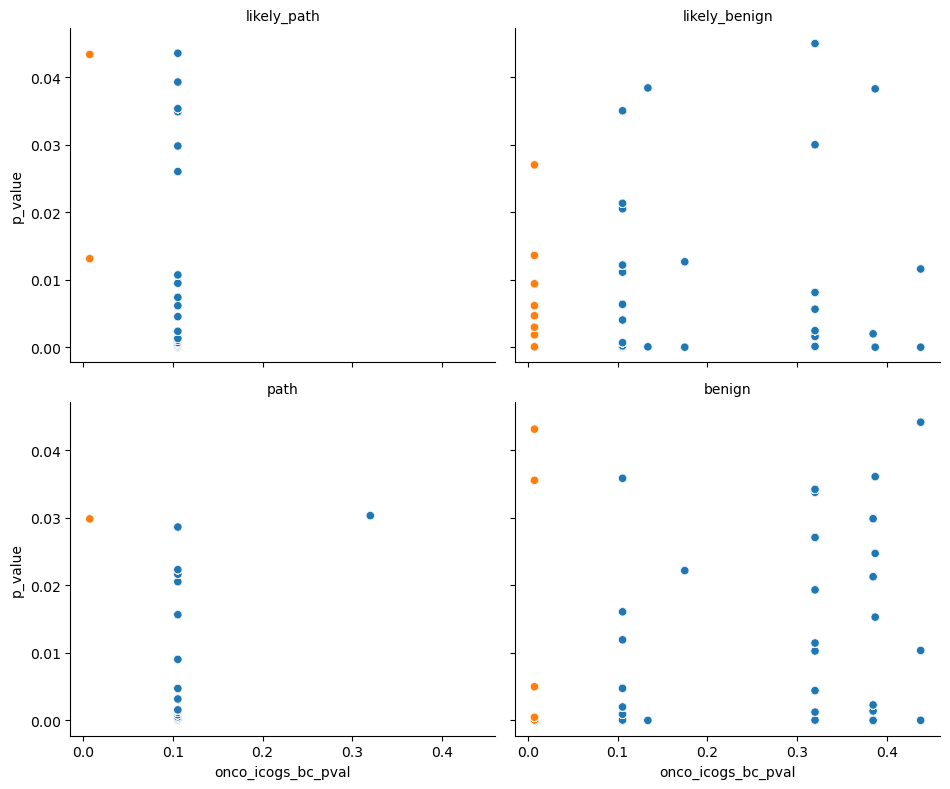

In [247]:
gwas_vep["z_score_abs"] = gwas_vep["z_score"].abs()
gwas_vep["onco_icogs_oc_sig"] = gwas_vep["onco_icogs_oc_pval"] < 0.05
gwas_vep["onco_icogs_bc_sig"] = gwas_vep["onco_icogs_bc_pval"] < 0.05
gwas_vep["onco_bc_sig"] = gwas_vep["onco_bc_p"] < 0.05
 


# Create faceted subplots by clinsig
g = sns.FacetGrid(gwas_vep, col="clinsig", col_wrap=2, height=4, aspect=1.2)
g.map_dataframe(sns.scatterplot, x="onco_icogs_bc_pval", y="p_value", hue="onco_icogs_bc_sig")
g.set_titles(col_template="{col_name}")
g.tight_layout()

Text(0.5, 1.0, 'VEP Scores by BC Significance\np=6.98e-01, d=0.10')

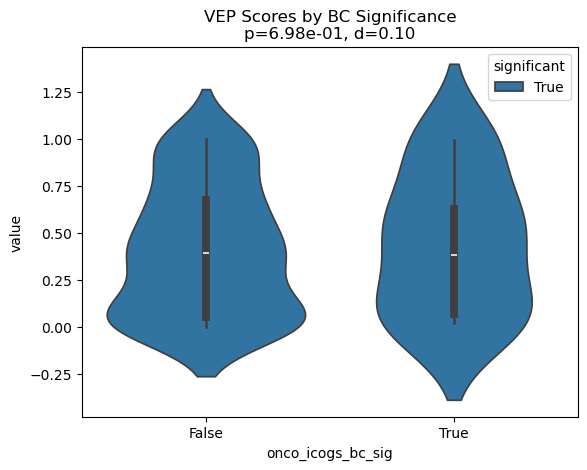

In [229]:


# Perform statistical test
from scipy import stats

# Perform t-test between the two groups
group1 = gwas_vep[gwas_vep['onco_icogs_bc_sig'] == True]['value']
group2 = gwas_vep[gwas_vep['onco_icogs_bc_sig'] == False]['value']

t_stat, p_value = stats.ttest_ind(group1, group2, nan_policy='omit')

# Calculate effect size (Cohen's d)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.var() + (n2-1)*group2.var()) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

effect_size = cohens_d(group1, group2)

# Create violin plot with stats in title
sns.violinplot(data=gwas_vep, x="onco_icogs_bc_sig", y="value", hue='significant')
plt.title(f'VEP Scores by BC Significance\np={p_value:.2e}, d={effect_size:.2f}')

gwas_vep['clinsig'].value_counts()

## Canonical BRCA1 missense risk variants

Source: https://chatgpt.com/share/684f32c8-3994-8008-9fb1-46b3a2525148

In [43]:
clinvar_variants = pd.DataFrame({
    'Protein_HGVS': ['p.Cys61Gly', 'p.Met1775Arg', 'p.Arg1699Gln', 'p.Trp1837Cys', 
                     'p.Gly1706Glu', 'p.Ala1708Val', 'p.Thr1685Pro', 'p.Asp1692His',
                     'p.Asp1692Asn', 'p.Gly1803Ala'],
    'Abbrev': ['C61G', 'M1775R', 'R1699Q', 'W1837C', 'G1706E', 'A1708V', 'T1685P',
               'D1692H', 'D1692N', 'G1803A'],
    'cDNA': ['c.181T>G', 'c.5324T>G', 'c.5096G>A', 'c.5511G>T', 'c.5117G>A', 
             'c.5123C>T', 'c.5053A>C', 'c.5074G>C', 'c.5074G>A', 'c.5408G>C'],
    'Domain': ['RING', 'BRCT', 'BRCT–N', 'BRCT2', 'BRCT', 'BRCT', 'BRCT', 'BRCT',
               'BRCT', 'BRCT2'],
    'Evidence_Strength': [
        'Pathogenic (ClinVar 3★, founder mutation, strong functional & segregation data）',
        'Pathogenic (ClinVar 3★, disrupted phosphopeptide binding, HDR loss）',
        'Pathogenic (reduced penetrance, expert-panel reviewed)',
        'Pathogenic (functional assays, hotspot residue)',
        'Pathogenic (functional impairment confirmed)',
        'Pathogenic (found in families, functionally deleterious)',
        'Likely Pathogenic (functional assays suggest loss)',
        'Pathogenic via splicing disruption (mini‑gene assay)',
        'Pathogenic via splicing effects',
        'Pathogenic via splice/truncation'
    ],
    'Support_PMIDs': [
        '7894493, 9525870, 11278247, 20103620, 20507347',
        '26913838, 30209399',
        '28490613, 23867111, 21473589, 11157798',
        '20516115, 27802165, 30209399, 31124283',
        '26913838, …',
        '26913838, …',
        '29185120',
        '29185120',
        '29185120',
        '29185120'
    ]
})
clinvar_variants


,Protein_HGVS,Abbrev,cDNA,Domain,Evidence_Strength,Support_PMIDs
0,p.Cys61Gly,C61G,c.181T>G,RING,"Pathogenic (ClinVar 3★, founder mutation, stro...","7894493, 9525870, 11278247, 20103620, 20507347"
1,p.Met1775Arg,M1775R,c.5324T>G,BRCT,"Pathogenic (ClinVar 3★, disrupted phosphopepti...","26913838, 30209399"
2,p.Arg1699Gln,R1699Q,c.5096G>A,BRCT–N,"Pathogenic (reduced penetrance, expert-panel r...","28490613, 23867111, 21473589, 11157798"
3,p.Trp1837Cys,W1837C,c.5511G>T,BRCT2,"Pathogenic (functional assays, hotspot residue)","20516115, 27802165, 30209399, 31124283"
4,p.Gly1706Glu,G1706E,c.5117G>A,BRCT,Pathogenic (functional impairment confirmed),"26913838, …"
5,p.Ala1708Val,A1708V,c.5123C>T,BRCT,"Pathogenic (found in families, functionally de...","26913838, …"
6,p.Thr1685Pro,T1685P,c.5053A>C,BRCT,Likely Pathogenic (functional assays suggest l...,29185120
7,p.Asp1692His,D1692H,c.5074G>C,BRCT,Pathogenic via splicing disruption (mini‑gene ...,29185120
8,p.Asp1692Asn,D1692N,c.5074G>A,BRCT,Pathogenic via splicing effects,29185120
9,p.Gly1803Ala,G1803A,c.5408G>C,BRCT2,Pathogenic via splice/truncation,29185120


In [ ]:
risk_variants = utils.intersect(clinvar_variants["Abbrev"].tolist(), clinical_vs_wt.columns.tolist())
print(len(risk_variants))
risk_variants 

7


['R1699Q', 'W1837C', 'G1803A', 'D1692H', 'G1706E', 'C61G', 'M1775R']

In [ ]:
large_del_rows = clinical_vs_wt.index[clinical_vs_wt.index.str.contains('del{')]
large_del_rows

Index(['13del{1852}'], dtype='object', name='variant')

Text(0.5, 1.0, 'VEP Scores by Variant Group\np=2.21e-03, d=0.43')

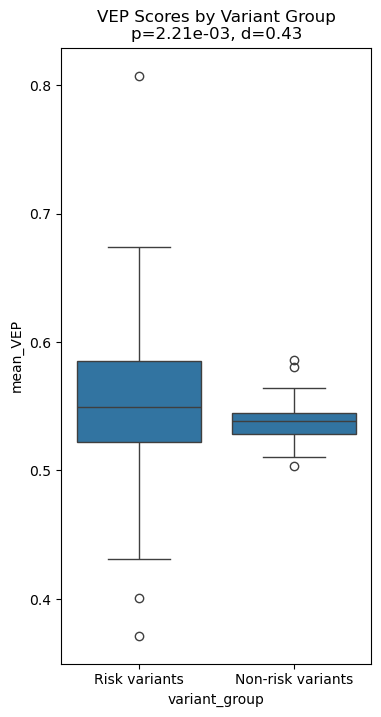

In [ ]:
dat = pd.concat([
    # Risk variants - exclude zeros and large deletions
    clinical_vs_wt[~clinical_vs_wt.index.isin(large_del_rows)][risk_variants].replace(0, np.nan).mean(axis=1, skipna=True).reset_index(name="mean_VEP").assign(variant_group="Risk variants"),
    # Non-risk variants - exclude zeros and large deletions
    clinical_vs_wt[~clinical_vs_wt.index.isin(large_del_rows)][clinical_vs_wt.columns.difference(risk_variants)].replace(0, np.nan).mean(axis=1, skipna=True).reset_index(name="mean_VEP").assign(variant_group="Non-risk variants")
], axis=0)
dat


# First ensure no duplicate labels in the data
dat = dat.reset_index(drop=True)

# Perform statistical test
from scipy import stats
# Handle NaN values by dropping them before statistical test
risk_data = dat[dat['variant_group'] == 'Risk variants']['mean_VEP'].dropna()
nonrisk_data = dat[dat['variant_group'] == 'Non-risk variants']['mean_VEP'].dropna()
stat, pval = stats.ttest_ind(risk_data, nonrisk_data)

# Calculate effect size (Cohen's d) manually since scipy.stats.cohens_d is not available
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)

effect_size = cohens_d(risk_data, nonrisk_data)

plt.figure(figsize=(4, 8))
sns.boxplot(data=dat, x="variant_group", y="mean_VEP")
plt.title(f'VEP Scores by Variant Group\np={pval:.2e}, d={effect_size:.2f}')

In [253]:
gwas_vep["is_risk_variant"] = gwas_vep["mutant"].isin(risk_variants)

In [257]:
gwas_vep["is_risk_variant"].value_counts() / gwas_vep.shape[0] 
 

is_risk_variant
False    0.9375
True     0.0625
Name: count, dtype: float64

In [102]:
gwas_vep.groupby(["clinsig","is_sig"])["site"].nunique()

clinsig  is_sig
benign   False     11
         True       3
path     False      1
         True       1
Name: site, dtype: int64

| rs_id       | chr | cytoband | position | ref_allele | alt_allele | freq_a1 | freq_a2 | odds_ratio | p_value    | beta    | se_beta  |
|-------------|-----|----------|----------|------------|------------|---------|---------|------------|------------|---------|----------|
| rs375280428 | 17  | 17q21.2  | 39254142 | G          | A          | 0.48    | 0.67    | 1.16       | 1.87E-09   | 1.15    | 2.90E-05 |
| rs58117746  | 17  | 17q21.2  | 39305775 | TGGCAGCAGCTGGGGC | T | 0.39    | 0.60    | 1.18       | 4.33E-10   | 1.15    | 7.72E-05 |
| rs11079012  | 17  | 17q21.2  | 39912880 | C          | G          | 0.69    | 0.66    | 0.86       | 7.06E-09   | 0.86    | 2.35E-05 |
| rs5820435   | 17  | 17q21.2  | 39961558 | C          | A          | 0.55    | 0.51    | 1.22       | 9.55E-12   | 1.17    | 2.72E-05 |

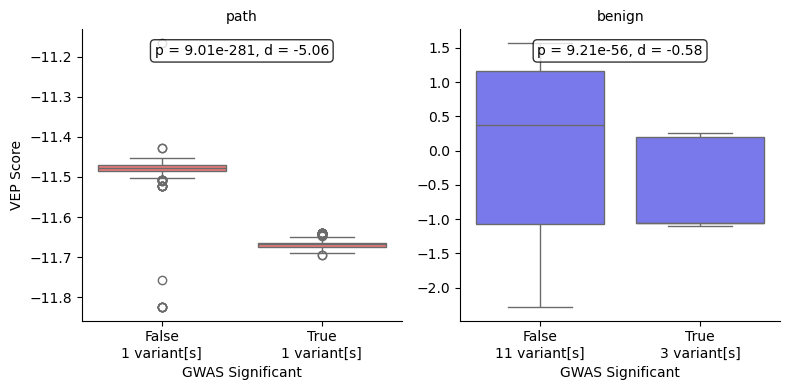

In [ ]:
gwas_vep["is_sig"] = gwas_vep["onco_icogs_bc_pval"] < 0.05
g = sns.FacetGrid(gwas_vep, col="clinsig", col_wrap=2, height=4, aspect=1, sharey=False, sharex=False)
g.map_dataframe(sns.boxplot, x="is_sig", y="VEP", hue="clinsig", palette=utils.get_clinsig_palette())
g.set_titles(col_template="{col_name}")
g.set_axis_labels("GWAS Significant", "VEP Score")

# Add n= counts and statistical test results under x-axis tick labels
for ax in g.axes.flat:
    # Get current tick positions and labels
    current_ticks = ax.get_xticks()
    current_labels = ax.get_xticklabels()
    
    # Get the clinical significance for this subplot
    clinsig = ax.get_title()
    
    # Filter data for this clinical significance
    subplot_data = gwas_vep[gwas_vep['clinsig'] == clinsig]
    
    # Perform statistical test if we have both groups
    if len(subplot_data['is_sig'].unique()) == 2:
        sig_data = subplot_data[subplot_data['is_sig'] == True]['VEP'].dropna()
        nonsig_data = subplot_data[subplot_data['is_sig'] == False]['VEP'].dropna()
        
        if len(sig_data) > 0 and len(nonsig_data) > 0:
            stat, pval = stats.ttest_ind(sig_data, nonsig_data)
            # Calculate effect size
            effect_size = cohens_d(sig_data, nonsig_data)
            pval_text = f"p = {pval:.2e}, d = {effect_size:.2f}"
        else:
            pval_text = "Insufficient data"
    else:
        pval_text = "Single group"
    
    # Create new labels with counts and p-values
    new_labels = []
    for i, tick in enumerate(current_labels):
        is_sig = tick.get_text()
        # Count data points for this combination
        count = gwas_vep[(gwas_vep['is_sig'] == (is_sig == "True")) & (gwas_vep['clinsig'] == clinsig)]["site"].nunique()
        new_labels.append(f"{is_sig}\n{count} variant(s)")
    
    # Set ticks and labels properly
    ax.set_xticks(current_ticks)
    ax.set_xticklabels(new_labels)
    
    # Add p-value text to subplot
    ax.text(0.5, 0.95, pval_text, transform=ax.transAxes, 
            ha='center', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
log_x = False
dat = gwas_vep.merge(clinical_vs_wt[risk_variants].max(axis=1, skipna=True).reset_index(name="mean_VEP"))
for col in ["onco_bc_p", "onco_bc_beta", "onco_oc_p","onco_oc_beta", "icogs2_bc_beta","icogs2_oc_beta", "onco_icogs_bc_effect","onco_icogs_bc_pval","onco_icogs_oc_pval","onco_icogs_oc_effect"]:
    
    if log_x:
        x_data = np.log10(dat[col])
    else:
        x_data = dat[col]

    sns.scatterplot(data=dat, x=x_data, y="mean_VEP", hue="clinsig")
    plt.show()


MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

### Muranen2020 GWAS

In [89]:
gwas_file = "/home/schilder/projects/data/GWAS/Muranen2020/B1_main_results_dominant.txt.gz"

import polars as pl


gwas_chr = pl.read_csv( gwas_file,
    separator="\t",
    # infer_schema_length=10000,  # Increase schema inference length
    null_values=["NULL","NA"],  # Add NULL to null values
    # schema_overrides={  # Specify dtypes for problematic columns
    #     "icogs2_bc_info": pl.Float64,
    #     "icogs2_bc_freq": pl.Float64,
    #     "icogs2_bc_effect": pl.Float64,
    #     "icogs2_bc_se": pl.Float64,
    #     "icogs2_bc_pval": pl.Float64
    # }
).filter(pl.col("chr")==17)

print(gwas_chr.shape)
gwas_chr.head()

(257236, 19)


variant,chr,position,reference_allele,effect_allele,beta,robust_se_beta,z,p_z,HR,HR_CI_95_lower,HR_CI_95_upper,p_LR,se_LR,BFDP_1.3,BFDP_1.8,BFDP_2.5,p_LR_age_interaction,FDR_age_interaction
str,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rs62053745:828:T:C""",17,828,"""T""","""C""",0.204873,0.247802,0.82676,0.408373,1.227369,0.755172,1.994823,0.372387,0.229675,0.999905,0.999922,0.999939,0.999702,0.999982
"""rs9747082:834:G:A""",17,834,"""G""","""A""",0.135818,0.361185,0.376035,0.706891,1.145474,0.564344,2.32502,0.682606,0.332148,0.999905,0.999921,0.999936,0.608999,0.982291
"""rs62053747:1389:G:A""",17,1389,"""G""","""A""",0.337421,0.14811,2.278172,0.022716,1.401329,1.048258,1.87332,0.028129,0.153689,0.999762,0.999643,0.999681,0.432587,0.971524
"""rs34151105:1665:T:C""",17,1665,"""T""","""C""",0.024626,0.136608,0.180266,0.856943,1.024932,0.784176,1.339603,0.861865,0.141528,0.999928,0.999958,0.999972,0.359327,0.965909
"""rs77383171:1880:C:T""",17,1880,"""C""","""T""",-0.04101,0.11209,-0.365864,0.714466,0.95982,0.77051,1.195642,0.713567,0.111722,0.999933,0.999963,0.999975,0.905014,0.996668


In [90]:
brca1_coords ="chr17:41196312-41277381" # They use hg37 coordinates in this GWAS, so we will too
gwas_brca1 = gwas_chr.filter(
    (pl.col("position")>=int(brca1_coords.split(":")[1].split("-")[0])) &
    (pl.col("position")<=int(brca1_coords.split(":")[1].split("-")[1]))
).to_pandas() 

print(gwas_brca1.shape)
gwas_brca1.head()

(224, 19)


,variant,chr,position,reference_allele,effect_allele,beta,robust_se_beta,z,p_z,HR,HR_CI_95_lower,HR_CI_95_upper,p_LR,se_LR,BFDP_1.3,BFDP_1.8,BFDP_2.5,p_LR_age_interaction,FDR_age_interaction
0,rs8176320,17,41196363,C,T,-0.134776,0.300436,-0.448601,0.653719,0.873912,0.484993,1.574705,0.639595,0.287820,0.999907,0.999926,0.999942,0.475700,0.974317
1,chr17_41196408_A_G,17,41196408,G,A,-0.217814,0.094010,-2.316926,0.020508,0.804275,0.668934,0.966999,0.020524,0.094022,0.999653,0.999656,0.999740,0.720192,0.988322
2,rs33947868:41196821:CT:C,17,41196821,CT,C,-0.171519,0.104785,-1.636867,0.101658,0.842384,0.685988,1.034435,0.101014,0.104588,0.999859,0.999891,0.999922,0.195262,0.945345
3,chr17_41197274_A_C,17,41197274,C,A,-0.217814,0.094010,-2.316926,0.020508,0.804275,0.668934,0.966999,0.020524,0.094022,0.999653,0.999656,0.999740,0.720192,0.988322
4,rs147297981:41198270:G:A,17,41198270,G,A,-0.042357,0.308537,-0.137284,0.890806,0.958527,0.523573,1.754817,0.890235,0.306921,0.999908,0.999928,0.999945,0.137117,0.932287


In [100]:
gwas_brca1.loc[gwas_brca1["p_LR"]<0.05]

,variant,chr,position,reference_allele,effect_allele,beta,robust_se_beta,z,p_z,HR,HR_CI_95_lower,HR_CI_95_upper,p_LR,se_LR,BFDP_1.3,BFDP_1.8,BFDP_2.5,p_LR_age_interaction,FDR_age_interaction
1,chr17_41196408_A_G,17,41196408,G,A,-0.217814,0.094010,-2.316926,0.020508,0.804275,0.668934,0.966999,0.020524,0.094022,0.999653,0.999656,0.999740,0.720192,0.988322
3,chr17_41197274_A_C,17,41197274,C,A,-0.217814,0.094010,-2.316926,0.020508,0.804275,0.668934,0.966999,0.020524,0.094022,0.999653,0.999656,0.999740,0.720192,0.988322
5,rs8176314:41198621:A:G,17,41198621,A,G,-0.219165,0.094043,-2.330464,0.019782,0.803189,0.667987,0.965757,0.019757,0.094024,0.999646,0.999645,0.999732,0.704454,0.987478
6,rs71359598:41198774:C:CA,17,41198774,C,CA,-0.186087,0.094066,-1.978265,0.047899,0.830201,0.690422,0.998280,0.048210,0.094197,0.999787,0.999822,0.999871,0.586337,0.980654
9,rs8176310:41199913:T:C,17,41199913,T,C,-0.187715,0.093397,-2.009851,0.044447,0.828851,0.690203,0.995351,0.045931,0.094044,0.999777,0.999813,0.999863,0.853983,0.994816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,rs149141411:41275081:G:GA,17,41275081,G,GA,-0.201070,0.093831,-2.142890,0.032122,0.817855,0.680467,0.982982,0.032397,0.093981,0.999732,0.999758,0.999821,0.687623,0.986765
219,rs8176083:41275151:G:C,17,41275151,G,C,-0.208616,0.093729,-2.225739,0.026032,0.811707,0.675488,0.975397,0.026365,0.093937,0.999698,0.999715,0.999787,0.799927,0.992619
220,rs8176082:41275645:A:G,17,41275645,A,G,-0.209167,0.093731,-2.231578,0.025643,0.811259,0.675112,0.974863,0.025977,0.093942,0.999695,0.999712,0.999785,0.792810,0.992257
221,rs3765640:41276247:A:G,17,41276247,A,G,-0.209167,0.093731,-2.231578,0.025643,0.811259,0.675112,0.974863,0.025977,0.093942,0.999695,0.999712,0.999785,0.792810,0.992257


In [102]:
outlier_sig.sort_values('z_score', key=lambda x: x.abs(), ascending=False)

,clinical_variant,wt_variant,value,outlier_type,z_score,p_value,p_adjusted,significant,wt_position,clinical_position,mutant,clinsig
21,V1687I,1706G>A,1.000000,high,9.970774,0.000000,0.000000,True,1706,1687,V1687I,likely_benign
43,T1802A,1804V>D,1.000000,high,9.890629,0.000000,0.000000,True,1804,1802,T1802A,likely_benign
0,I1432L,1433I>V,0.000000,low,-9.844281,0.000000,0.000000,True,1433,1432,I1432L,likely_benign
22,V1687G,1706G>A,0.000000,low,-9.743447,0.000000,0.000000,True,1706,1687,V1687G,likely_path
17,T1684A,1706G>A,0.000000,low,-9.711936,0.000000,0.000000,True,1706,1684,T1684A,likely_benign
...,...,...,...,...,...,...,...,...,...,...,...,...
409,G1738R,1710G>R,1.000000,high,4.515091,0.000006,0.000025,True,1710,1738,G1738R,path
410,L1664P,1652M>I,0.000000,low,-4.513271,0.000006,0.000025,True,1652,1664,L1664P,benign
411,D1733G,1706G>A,0.086647,low,-4.511982,0.000006,0.000025,True,1706,1733,D1733G,benign
412,K1648T,1652M>I,0.694328,high,4.511715,0.000006,0.000025,True,1652,1648,K1648T,likely_benign


## Multi-Mutant DMS

Benchmark inferred interactions against the multi-mutant DMS datasets

In [ ]:
multi_dms_df = pg.get_multi_dms(keys=["DMS_ProteinGym_substitutions.zip"])
# Subset to just HUMAN
multi_dms_df = multi_dms_df.loc[multi_dms_df["species"] == "HUMAN"]

print(multi_dms_df.shape)
multi_dms_df 

Checking for multi-mutant files: 100%|██████████| 217/217 [00:09<00:00, 23.69it/s]

(23, 5)


,protein,source_file,n_multi_mutants,gene,species
64,A4_HUMAN_Seuma_2022,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,14015,A4,HUMAN
5,AMFR_HUMAN_Tsuboyama_2023_4G3O,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,2152,AMFR,HUMAN
15,CBPA2_HUMAN_Tsuboyama_2023_1O6X,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,711,CBPA2,HUMAN
29,CBX4_HUMAN_Tsuboyama_2023_2K28,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,1365,CBX4,HUMAN
39,DLG4_HUMAN_Faure_2021,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,5696,DLG4,HUMAN
9,DNJA1_HUMAN_Tsuboyama_2023_2LO1,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,1048,DNJA1,HUMAN
14,EPHB2_HUMAN_Tsuboyama_2023_1F0M,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,721,EPHB2,HUMAN
7,GRB2_HUMAN_Faure_2021,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,62332,GRB2,HUMAN
43,HECD1_HUMAN_Tsuboyama_2023_3DKM,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,4342,HECD1,HUMAN
57,NKX31_HUMAN_Tsuboyama_2023_2L9R,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,1333,NKX31,HUMAN


### Check for overlap between clinical VEP and DMS data.

In [ ]:
overlap_df = ab.check_multi_dms_overlap(multi_dms_df, vep_files)
overlap_df

Iterating over DMS file:   9%|▊         | 2/23 [00:00<00:04,  4.77it/s]

No rows in vep_files found.
No rows in vep_files found.


Iterating over DMS file:  17%|█▋        | 4/23 [00:00<00:03,  5.56it/s]

No rows in vep_files found.
No rows in vep_files found.
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 78 masked-marginals parquet files


Reading files:   0%|          | 0/78 [00:00<?, ?it/s]

...

Reading files:   0%|          | 0/112 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 3.71GB/s]
Iterating over DMS file: 100%|██████████| 23/23 [00:08<00:00,  2.79it/s]

VEP dataframe shape: (672, 72)
haplotypes: 23
vep_matrix shape:  (23, 6)
wt_matrix shape:  (23, 23)
interaction_dms (by hgvs): (0, 25)
interaction_dms (by position): (0, 25)


,gene,source_file,wt_vs_mut1,wt_vs_mut2,site_vs_mut1,site_vs_mut2,wtpos_vs_mut1pos,wtpos_vs_mut2pos,sitepos_vs_mut1pos,sitepos_vs_mut2pos
0,DLG4,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,0,0,0,0,0,0,0,0
1,PITX2,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,0,0,0,0,0,0,0,0
2,YAP1,/home/schilder/.cache/ProteinGym/v1.1/DMS_Prot...,1,1,0,0,1,1,0,0
